# Libs, data, functions

## Libraries

In [76]:
# !pip install mne
# !pip install spkit

In [77]:
# !pip install neurodsp

In [78]:
# NeuroDSP
from neurodsp.spectral import compute_spectrum, rotate_powerlaw
from neurodsp.utils import create_times
from neurodsp.utils.download import load_ndsp_data
from neurodsp.plts.spectral import plot_power_spectra
from neurodsp.plts.time_series import plot_time_series
# MNE
import mne.time_frequency
# Other
from scipy.io import loadmat
from mne.preprocessing import ICA, corrmap, create_ecg_epochs, create_eog_epochs
import spkit as sp
from spkit.data import load_data
import numpy as np
from sklearn.decomposition import PCA
import plotly
from scipy import signal
from scipy.signal import savgol_filter
from scipy.signal import iirdesign
from scipy.signal import butter, filtfilt
from scipy.signal import find_peaks
from scipy.stats import zscore
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import mode
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from scipy.interpolate import interp1d
import mne
import math
import bisect
import h5py
from tqdm import tqdm
import os
import DeepNeuralNetworkSleep.hdf5_files.Artefacts_Detection as A

## Frequency bands

In [79]:
# Rodent Frequency bands
noise_band = [0,0.5]
delta_band = [0.5,5]
theta_band = [6,10]
sigma_band = [11,17]
beta_band = [22,30]
gamma_band = [35,45]
total_band = [0,30]

In [80]:
# Human frequency bands (AASM)
# noise_band = [0,0.49]
# delta_band = [0.5,3.99]
# theta_band = [4,7.99]
alpha_band = [8,12]
# sigma_band = [12,15.99]
# beta_band = [16,29.99]
# gamma_band = [30,40]
# total_band = [0,40]



## Functions



In [81]:
# Using MNE's multitapering (~3-4min)

def psd_multitaper(lfp_data, fs, frequency_band):
    all_power_sum = []
    
    # loop through each segment
    for start in range(0, len(lfp_data) - window_length + 1, window_length):
        window = lfp_data[start:min(start + window_length, len(lfp_data))]

        # compute power spectral density using multitaper method
        psd, freqs = mne.time_frequency.psd_array_multitaper(window, fs, fmin=frequency_band[0], fmax=frequency_band[1], n_jobs=1, verbose = 'warning')

        # compute total power within frequency band
        freq_indices = (freqs >= frequency_band[0]) & (freqs <= frequency_band[1])
        curr_sum = np.sum(psd)
        all_power_sum.append(curr_sum)

    return all_power_sum

### Power ratios functions

In [82]:
def PRnoise(noise, total):
  prnoise = np.array([])
  for i in range(len(noise)):
    value = (noise[i])/total[i]
    prnoise = np.append(prnoise, [value])
  return prnoise

In [83]:
def PRdelta(delta, total):
  prdelta = np.array([])
  for i in range(len(delta)):
    value = (delta[i])/total[i]
    prdelta = np.append(prdelta, [value])
  return prdelta

In [84]:
def PRsigma(sigma, total):
  prsigma = np.array([])
  for i in range(len(sigma)):
    value = (sigma[i])/total[i]
    prsigma = np.append(prsigma, [value])
  return prsigma

### Wei indexes functions

In [85]:
def index_W(delta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/delta[i]
    index_w = np.append(index_w, [value])
  return index_w

In [86]:
def index_N(delta, sigma, gamma):
  index_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i])/(gamma[i]**2)
    index_n = np.append(index_n, [value])
  return index_n    

In [87]:
def index_R(delta, theta, sigma, EMG):
  index_r = np.array([])
  for i in range(len(delta)):
    value = (theta[i]**3)/(delta[i]*sigma[i]*EMG[i])
    index_r = np.append(index_r, [value])
  return index_r

In [88]:
def index_A(noise, delta, theta, sigma, beta, gamma):
  index_a = np.array([])
  for i in range(len(beta)):
    value = ((2*noise[i]+beta[i])*gamma[i])/(delta[i]+theta[i]+sigma[i]+beta[i]+gamma[i])
    index_a = np.append(index_a, [value])
  return index_a

In [89]:
def Artefact_index(index_A, index_N, index_R):
  artefact_index = np.array([])
  for i in range(len(index_A)):
    value = index_A[i]/(index_N[i]+index_R[i]+index_A[i])
    artefact_index = np.append(artefact_index, [value])
  return artefact_index

In [90]:
def Index_1(delta, gamma, EMG):
  index_1 = np.array([])
  for i in range(len(delta)):
    value = (EMG[i]*gamma[i])/(delta[i])
    index_1 = np.append(index_1, [value])
  return index_1

In [91]:
def Index_2(delta, theta, sigma):
  index_2 = np.array([])
  for i in range(len(delta)):
    value = (sigma[i]*delta[i])/(theta[i])
    index_2 = np.append(index_2, [value])
  return index_2

In [92]:
def Index_3(delta, theta, gamma):
  index_3 = np.array([])
  for i in range(len(delta)):
    value = (theta[i]*gamma[i])/(delta[i])
    index_3 = np.append(index_3, [value])
  return index_3

In [93]:
def Index_4(delta, theta):
  index_4 = np.array([])
  for i in range(len(delta)):
    value = delta[i]/theta[i]
    index_4 = np.append(index_4, [value])
  return index_4

### New indices functions

In [94]:
def nindex_W(theta, gamma, EMG):
  index_w = np.array([])
  for i in range(len(theta)):
    value = EMG[i]*EMG[i]*((gamma[i])/(theta[i]))
    index_w = np.append(index_w, [value])
  return index_w

def nindex_R(delta, theta, sigma, EMG, gamma):
  nindex_r = np.array([])
  for i in range(len(delta)):
    value = ((theta[i]*2)*gamma[i])/(delta[i]*delta[i]*EMG[i]**2)
    nindex_r = np.append(nindex_r, [value])
  return nindex_r

def nindex_N(delta, sigma, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(EMG_norm[i]*theta[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_N2(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = (delta[i]*sigma[i]*sigma[i]/(EMG[i]*gamma[i]**2))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

def nindex_N3(delta, theta, sigma, EMG, gamma):
  nindex_n = np.array([])
  for i in range(len(delta)):
    value = ((sigma[i])/(gamma[i]*EMG[i]*gamma[i]*theta[i]))
    nindex_n = np.append(nindex_n, [value])
  return nindex_n

### Wei normalisation

In [95]:
def wei_normalizing(data):
    data = np.array(data)

    bottom = data[data <= np.nanpercentile(data, 10, axis=0)]
    top = data[data >= np.nanpercentile(data, 90, axis=0)]

    bottom_avg = np.average(bottom) if len(bottom) > 0 else 0
    top_avg = np.average(top) if len(top) > 0 else 1

    denom = top_avg - bottom_avg if top_avg != bottom_avg else 1
    normalized_data = (data - bottom_avg) / denom
    normalized_data = np.clip(normalized_data, 0.05, 1)

    return normalized_data

In [96]:
def plots(new_features, mapped_scores):

  epochs = np.arange(len(mapped_scores))
  fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))
  # Plot data on each subplot
  ax1.plot(epochs, new_features[:,0], label='Index W', color='black')
  ax1.plot(epochs, new_features[:,2], label='Index N', color='blue')
  ax1.plot(epochs, new_features[:,1], label='Index R', color='red')

  ax1.plot(epochs, new_features[:,0], label='Index W', color='black')
  ax1.plot(epochs, new_features[:,2], label='Index N', color='blue')
  ax1.plot(epochs, new_features[:,1], label='Index R', color='red')

  ax2.plot(epochs, mapped_scores, label='Mapped scores')

  # Add legends
  ax1.legend()
  ax2.legend()
  # Add titles
  ax1.set_title('New indices')
  ax2.set_title('Mapped scores')
  # Adjust layout to avoid overlap
  plt.tight_layout()
  # Show the plots
  plt.show()


  # Barplot
  index_Wake = [[],[],[]]
  index_NREM = [[],[],[]]
  index_REM = [[],[],[]]
  for i, el in enumerate(mapped_scores):

    if el == 'Wake':
      index_Wake[0].append(new_features[:,0][i])
      index_Wake[1].append(new_features[:,1][i])
      index_Wake[2].append(new_features[:,2][i])
    elif el == 'NREM':
      index_NREM[0].append(new_features[:,0][i])
      index_NREM[1].append(new_features[:,1][i])
      index_NREM[2].append(new_features[:,2][i])
    elif el == 'REM':
      index_REM[0].append(new_features[:,0][i])
      index_REM[1].append(new_features[:,1][i])
      index_REM[2].append(new_features[:,2][i])

  wake_w = np.average(index_Wake[0])
  wake_r = np.average(index_Wake[1])
  wake_n = np.average(index_Wake[2])
  NREM_w = np.average(index_NREM[0])
  NREM_r = np.average(index_NREM[1])
  NREM_n = np.average(index_NREM[2])
  REM_w = np.average(index_REM[0])
  REM_r = np.average(index_REM[1])
  REM_n = np.average(index_REM[2])

  if 'Wake' not in mapped_scores:
    nwake_w = 0
    nwake_r = 0
    nwake_n = 0
  if 'REM' not in mapped_scores:
    nREM_w = 0
    nREM_r = 0
    nREM_n = 0
  if 'NREM' not in mapped_scores:
    nNREM_w = 0
    nNREM_r = 0
    nNREM_n = 0

  plt.figure(figsize=(12, 6))
  # Wei indexes
  plt.subplot(1, 2, 1)
  categories = ['Wake', 'NREM', 'REM']
  index_types = ['Index_w', 'Index_r', 'Index_n']
  values_wake = [wake_w, NREM_w, REM_w]
  values_REM = [wake_r, NREM_r, REM_r]
  values_NREM = [wake_n, NREM_n, REM_n]
  x = np.arange(len(categories))
  bar_width = 0.2
  # Create bar plots
  plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
  plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
  plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
  # Add labels and title
  plt.xlabel('Sleep Stages')
  plt.ylabel('Average Index Values')
  plt.title('New indexes')
  plt.xticks(x, categories)
  plt.legend()

  for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom')
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom')
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom')

In [97]:
def spike_conflict_avg(arraya, arrayb):
    avg = (arraya + arrayb) / 2
    agreement = 1- np.abs(arraya - arrayb)
    result = avg + (arraya * arrayb - (1 - arraya) * (1-arrayb)) * (agreement - 0.5)
    result = np.clip(result, 0, 1)
    return result

In [98]:
def cross_correlation(EOG1, EOG2, epoch_length, fs, lag=0):
    samples = int(epoch_length * fs)
    cross_cor_epochs = []

    for i in range(0, len(EOG1) - len(EOG1) % samples, samples):
        epoch1 = EOG1[i:i + samples]
        epoch2 = EOG2[i:i + samples]
        cc_full = np.correlate(epoch1, epoch2, mode='full')
        center = len(cc_full) // 2
        cross_cor_epochs.append(cc_full[center + lag])

    return cross_cor_epochs

def auto_correlation_slope(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    slopes = []

    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        ac = np.correlate(epoch, epoch, mode='full')
        center = len(ac) // 2
        ac = ac[center:]
        peaks, _ = find_peaks(ac)
        if len(peaks) < 1:
            slopes.append(0)
            continue
        first_peak_idx = peaks[0]
        slope = (ac[first_peak_idx] - ac[0]) / first_peak_idx
        slopes.append(slope)

    return slopes

def auto_correlation(EOG, epoch_length, fs):
    samples = int(epoch_length * fs)
    auto_corr = np.array([])
    for i in range(0, len(EOG) - len(EOG) % samples, samples):
        epoch = EOG[i:i + samples]
        squared = np.sum(epoch*epoch)
        auto_corr = np.append(auto_corr, squared)
    return(auto_corr)

def rem_feature(EOG1, EOG2, epoch_length, fs):
    rem_features = np.array([])
    b, a = butter(4, [0.3 / (0.5 * fs), 35 / (0.5 * fs)], btype='band')
    EOG1 = filtfilt(b, a, EOG1)
    EOG2 = filtfilt(b, a, EOG2)
    cross_cor_val = cross_correlation(EOG1, EOG2, epoch_length, fs, 0)
    auto_slope = auto_correlation_slope(EOG1, epoch_length, fs)
    for count, slope in enumerate(auto_slope):
        eog_feature = (1/slope)*np.sign(cross_cor_val[count])
        rem_features = np.append(rem_features, eog_feature)
    return rem_features

In [99]:
def fragment_join(subject, night, type):
    base = f"C:/EEG_Data_stage/{subject}/iEEG/{type}"
    score_base = f"C:/EEG_Data_stage/{subject}/iEEG/scores"
    files = []
    scores = []
    for file in os.listdir(base):
        if f"night{night}" in file and ".vhdr" in file:
            files.append(os.path.join(base,file))
            scores.append(os.path.join(score_base,file.replace(".vhdr", "_hypnogram.npy")))
    return files, scores        

## Loading Data

In [100]:
subject = "2"
night = "2"
file_type = "converted_extra_adj_intra"
hpc_channel = 'TR10-TR09'
pfc_channel = "TL01-TL02"
os.makedirs(os.path.join("C:/EEG_Data_stage","plots_bi_intra", file_type, subject, f"night{night}"), exist_ok=True)
output_dir = os.path.join("C:/EEG_Data_stage","plots_bi_intra", file_type, subject, f"night{night}")


In [101]:
fs = 250  # EEG sampling frequency
window_length = 10 * fs
epoch_length = int(window_length / fs)

In [102]:
files, scores_files = fragment_join(subject, night, file_type)

raw_list = [mne.io.read_raw_brainvision(f, preload=True) for f in files]
raw = mne.concatenate_raws(raw_list)
raw.filter(l_freq=10, h_freq=70, picks='EMG1-EMG2')
hpc_data = raw.get_data(picks=hpc_channel)[0]
hpc_tag = hpc_channel
raw_hpc = np.ravel(hpc_data)
pfc_data = raw.get_data(picks=pfc_channel)[0]
pfc_tag = pfc_channel
raw_pfc = np.ravel(pfc_data)

Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night2_01.vhdr...
Setting channel info structure...
Reading 0 ... 2950863  =      0.000 ... 11803.452 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night2_02.vhdr...
Setting channel info structure...
Reading 0 ... 3599983  =      0.000 ... 14399.932 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night2_03.vhdr...
Setting channel info structure...
Reading 0 ... 3600015  =      0.000 ... 14400.060 secs...
Extracting parameters from C:/EEG_Data_stage/2/iEEG/converted_extra_adj_intra\2_night2_04.vhdr...
Setting channel info structure...
Reading 0 ... 1058335  =      0.000 ...  4233.340 secs...
Filtering a subset of channels. The highpass and lowpass values in the measurement info will not be updated.
Filtering raw data in 4 contiguous segments
Setting up band-pass filter from 10 - 70 Hz

FIR filter parameters
--------------------

In [103]:
score_list = [np.load(f) for f in scores_files]
states = np.concatenate(score_list)
# states = np.append(states, [0,0,0])
print(f"Raw length: {len(raw_hpc)}")
print(f"Raw length / 250: {len(raw_hpc) / 250}")
print(f"Raw time in hours: {len(raw_hpc) / 250 / 3600}")
print(f"Raw epoch count: {len(raw_hpc) / 250 / 10}")
print(f"Sleep state amount: {len(states)}")

Raw length: 11209200
Raw length / 250: 44836.8
Raw time in hours: 12.454666666666668
Raw epoch count: 4483.68
Sleep state amount: 4482


In [104]:
len(hpc_data)/(len(np.ravel(states)))

2500.937081659973

In [105]:
len(states)*2

8964

## Get powers and plots


### Get EMG

In [106]:
from scipy.signal import hilbert
EMG = raw.get_data(picks='EMG1-EMG2')[0]
EMG = EMG[:len(EMG)// (epoch_length * fs) * (epoch_length * fs)] 
EMG = EMG.reshape(-1, (epoch_length * fs))
EMG = EMG.sum(axis=1)
EMG = abs(hilbert(EMG))

In [107]:
amp_thresh = [10,5]         # 6σ for amplitude, 4σ for derivative
time_win_thresh = [0.2,0.1]
raw_hpc, inds, timeval = A.removeArtefacts(raw_hpc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)

In [108]:
raw_pfc, inds, timeval = A.removeArtefacts(raw_pfc, 250, amp_thresh, time_win_thresh)
indices = A.artefact_epochs(inds, window_length)

### Get mapped scores

In [109]:
sleep_scoring = np.ravel(states)
# reshaped_scores = sleep_scoring[:len(sleep_scoring) // epoch_length * epoch_length].reshape(-1, epoch_length)
# majority_scores = mode(sleep_scor, axis=1).mode.flatten()
score_labels = {0: 'Wake', 1: 'N1', 2:'N2', 3: 'N3', 4: 'REM'}
# majority_states = [score_labels[state] for state in sleep_scoring]
mapped_scores = np.array(sleep_scoring)
sleep_time_minutes = np.arange(0, len(sleep_scoring)) * epoch_length / 60
num_labels = {label: num for num, label in enumerate(score_labels.values(), start=1)}

In [110]:
### Get EOG
# EOG1, EOG2 = np.ravel(raw.get_data(picks='EOG1')[0]), np.ravel(raw.get_data(picks='EOG2')[0])

In [111]:
epochs = np.arange(len(mapped_scores))
hypno_epochs = epochs
print(epochs)

[   0    1    2 ... 4479 4480 4481]


### Get powers


In [112]:
from joblib import Parallel, delayed
raws = [np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_pfc), np.ravel(raw_hpc)]
fr_bands = [noise_band, delta_band, theta_band, sigma_band, beta_band, gamma_band, alpha_band]
noise, delta, theta, sigma, beta, gamma, alpha = Parallel(n_jobs=7)(delayed(psd_multitaper)(raw, fs, band) for raw, band in zip(raws, fr_bands))

In [113]:
noise_norm = wei_normalizing(noise)
delta_norm = wei_normalizing(delta)
theta_norm = wei_normalizing(theta)
sigma_norm = wei_normalizing(sigma)
beta_norm = wei_normalizing(beta)
gamma_norm = wei_normalizing(gamma)
alpha_norm = wei_normalizing(alpha)
#total_norm = wei_normalizing(total)
EMG_norm = wei_normalizing(EMG)
noise_smoothed = np.convolve(np.convolve(np.convolve(noise_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
theta_smoothed = np.convolve(np.convolve(np.convolve(theta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
delta_smoothed = np.convolve(np.convolve(np.convolve(delta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
alpha_smoothed = np.convolve(np.convolve(np.convolve(alpha_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
beta_smoothed = np.convolve(np.convolve(np.convolve(beta_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
sigma_smoothed = np.convolve(np.convolve(np.convolve(sigma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
gamma_smoothed = np.convolve(np.convolve(np.convolve(gamma_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
EMG = np.convolve(EMG, np.ones(20*fs)/(20*fs), mode='same')

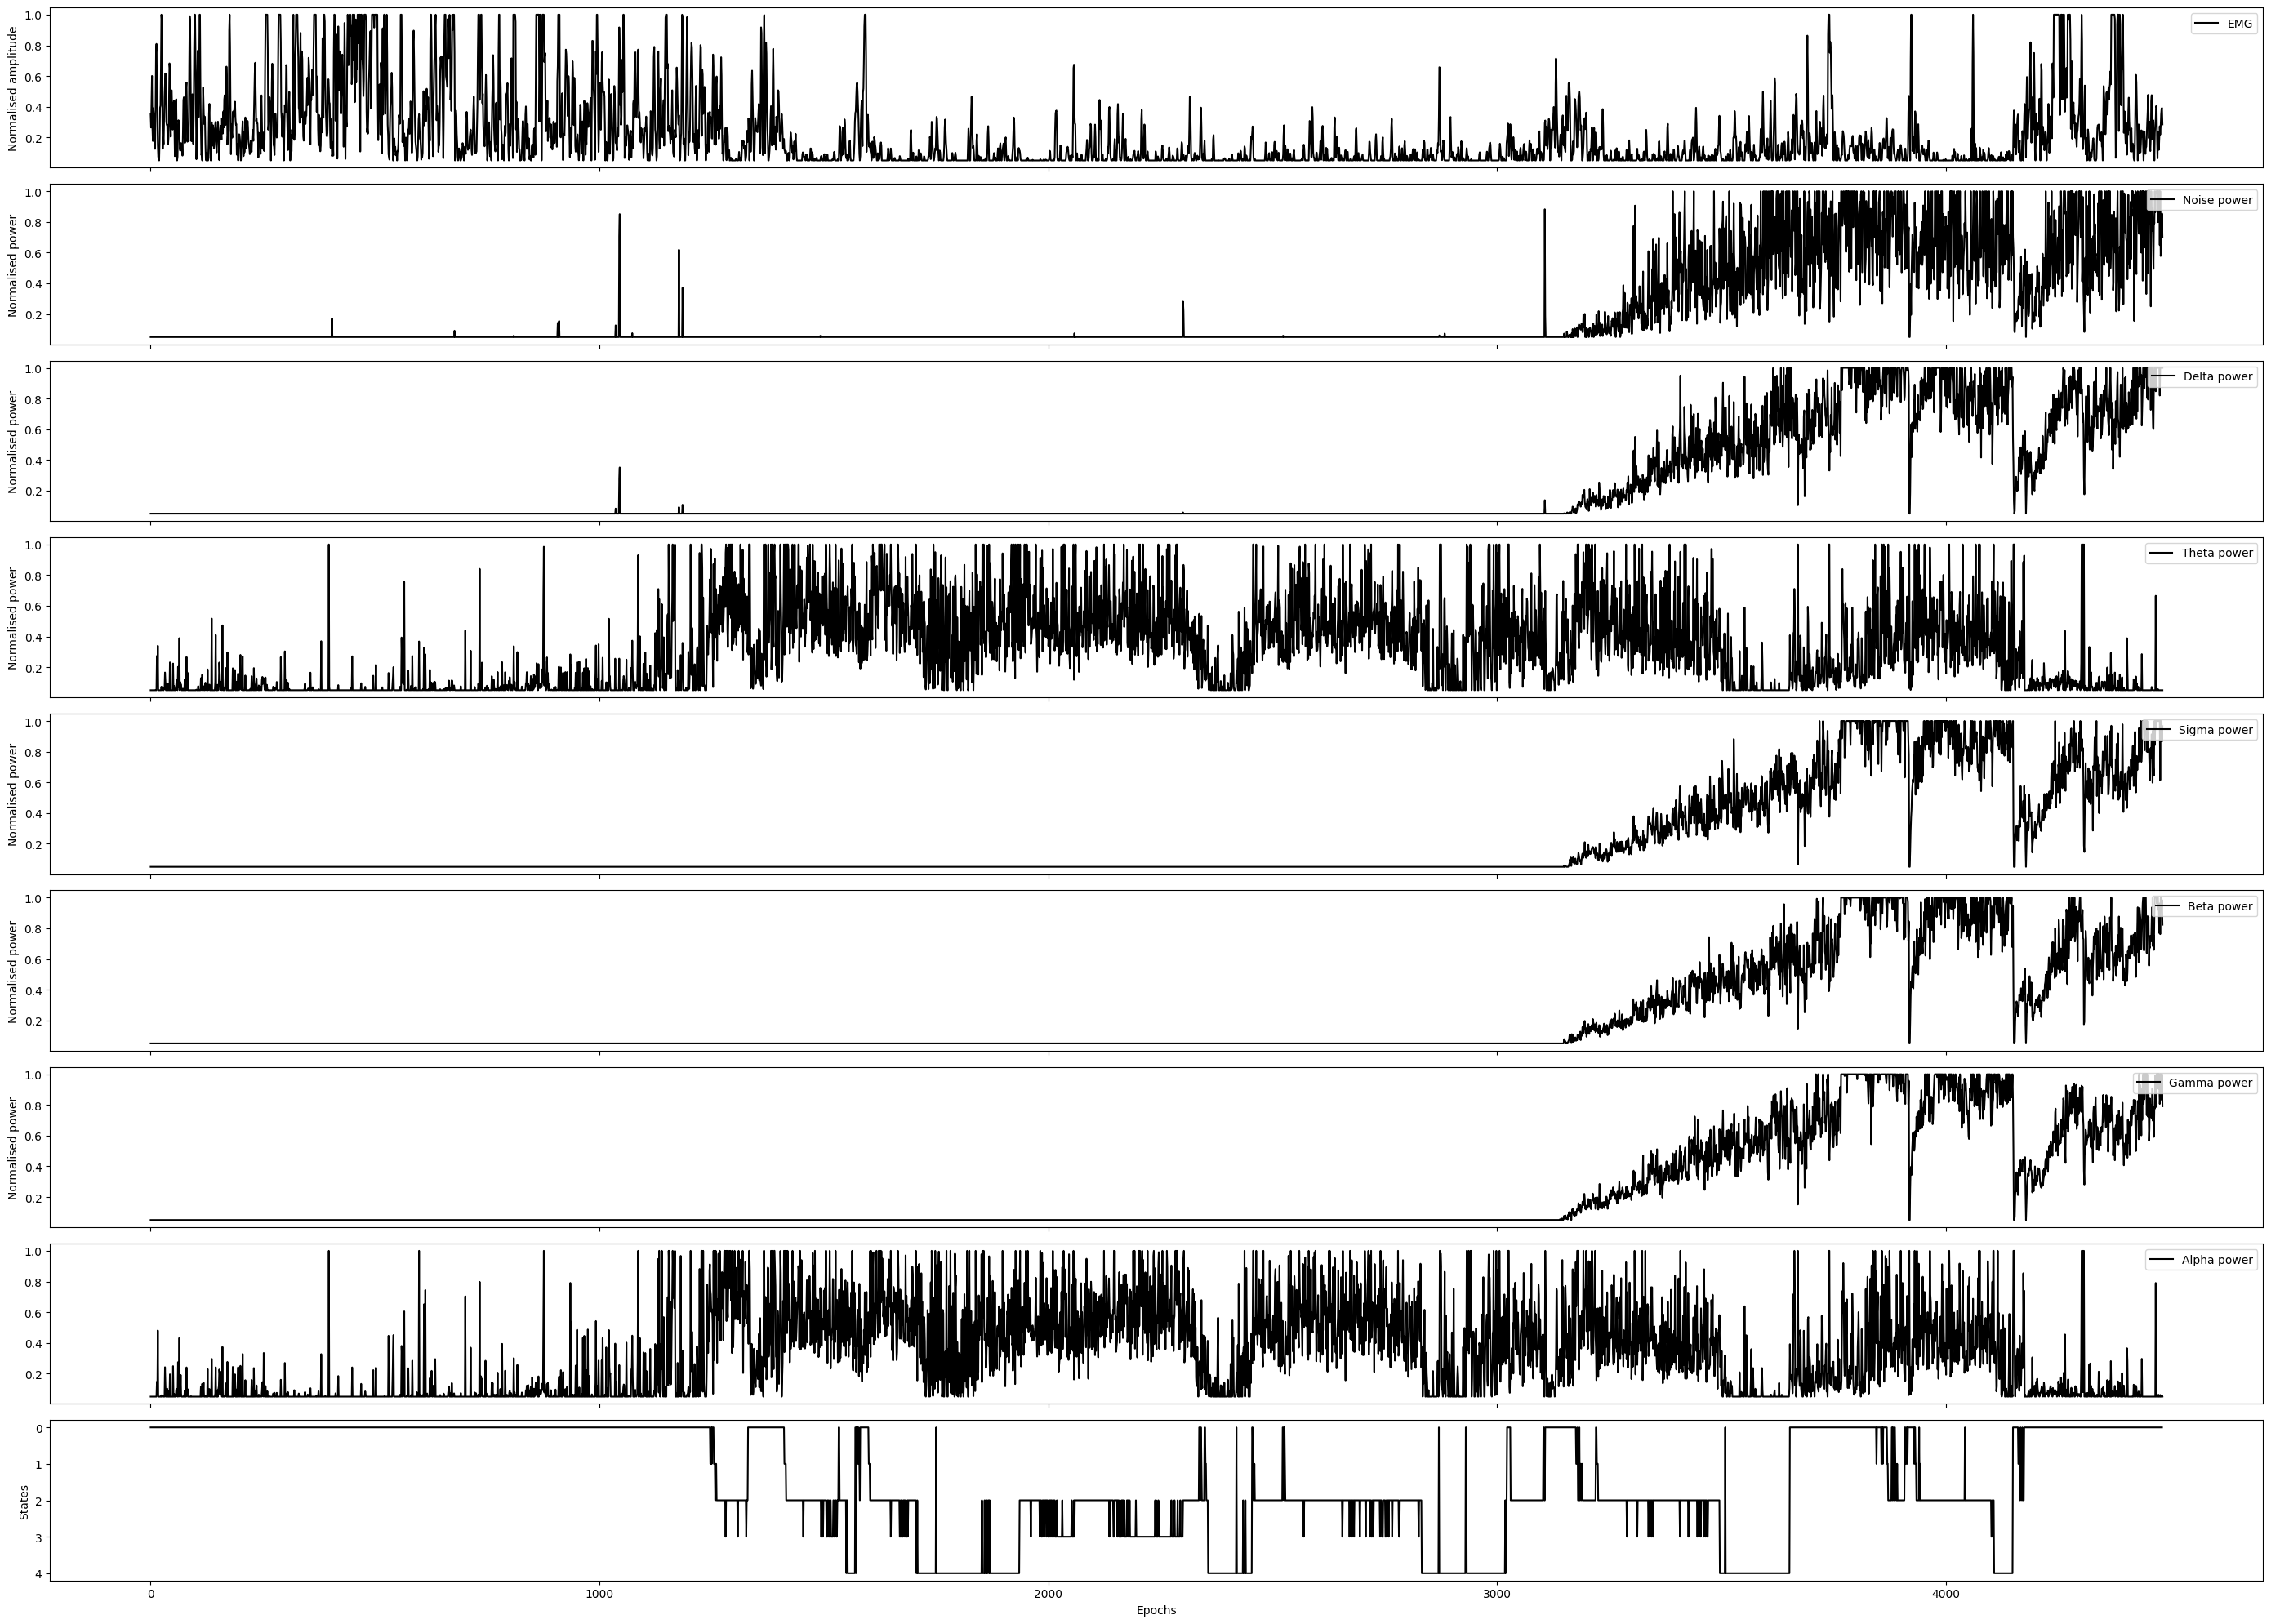

In [114]:
fig, (ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9) = plt.subplots(9, 1, sharex=True, figsize = (28, 20))
epochs = np.arange(len(EMG_norm))
# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='EMG', color = 'black')
ax2.plot(epochs, noise_norm, label='Noise power', color = 'black')
ax3.plot(epochs, delta_norm, label='Delta power', color = 'black')
ax4.plot(epochs, theta_norm, label='Theta power', color = 'black')
ax5.plot(epochs, sigma_norm, label='Sigma power', color = 'black')
ax6.plot(epochs, beta_norm, label='Beta power', color = 'black')
ax7.plot(epochs, gamma_norm, label='Gamma power', color = 'black')
ax8.plot(epochs, alpha_norm, label='Alpha power', color = 'black')
ax9.plot(hypno_epochs, sleep_scoring, label='Mapped scores', color = 'black')


ax1.legend(loc='upper right')
ax2.legend(loc='upper right')
ax3.legend(loc='upper right')
ax4.legend(loc='upper right')
ax5.legend(loc='upper right')
ax6.legend(loc='upper right')
ax7.legend(loc='upper right')
ax8.legend(loc='upper right')

ax1.set_ylabel('Normalised amplitude')
ax2.set_ylabel('Normalised power')
ax3.set_ylabel('Normalised power')
ax4.set_ylabel('Normalised power')
ax5.set_ylabel('Normalised power')
ax6.set_ylabel('Normalised power')
ax7.set_ylabel('Normalised power')
ax9.set_ylabel('States')
# ax8.set_yticks([0, 1, 2, 3, 4])
# ax8.set_yticklabels(state_labels)
ax9.invert_yaxis() 
ax9.set_xlabel('Epochs')
# Adjust layout to avoid overlap
plt.tight_layout()

plt.savefig(f"{output_dir}/Normalised_powers.svg", format='svg', dpi=300)
# Show the plots
plt.show()

### Plots

C:\Users\timmi\AppData\Local\Temp\ipykernel_1952\63535414.py:7: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



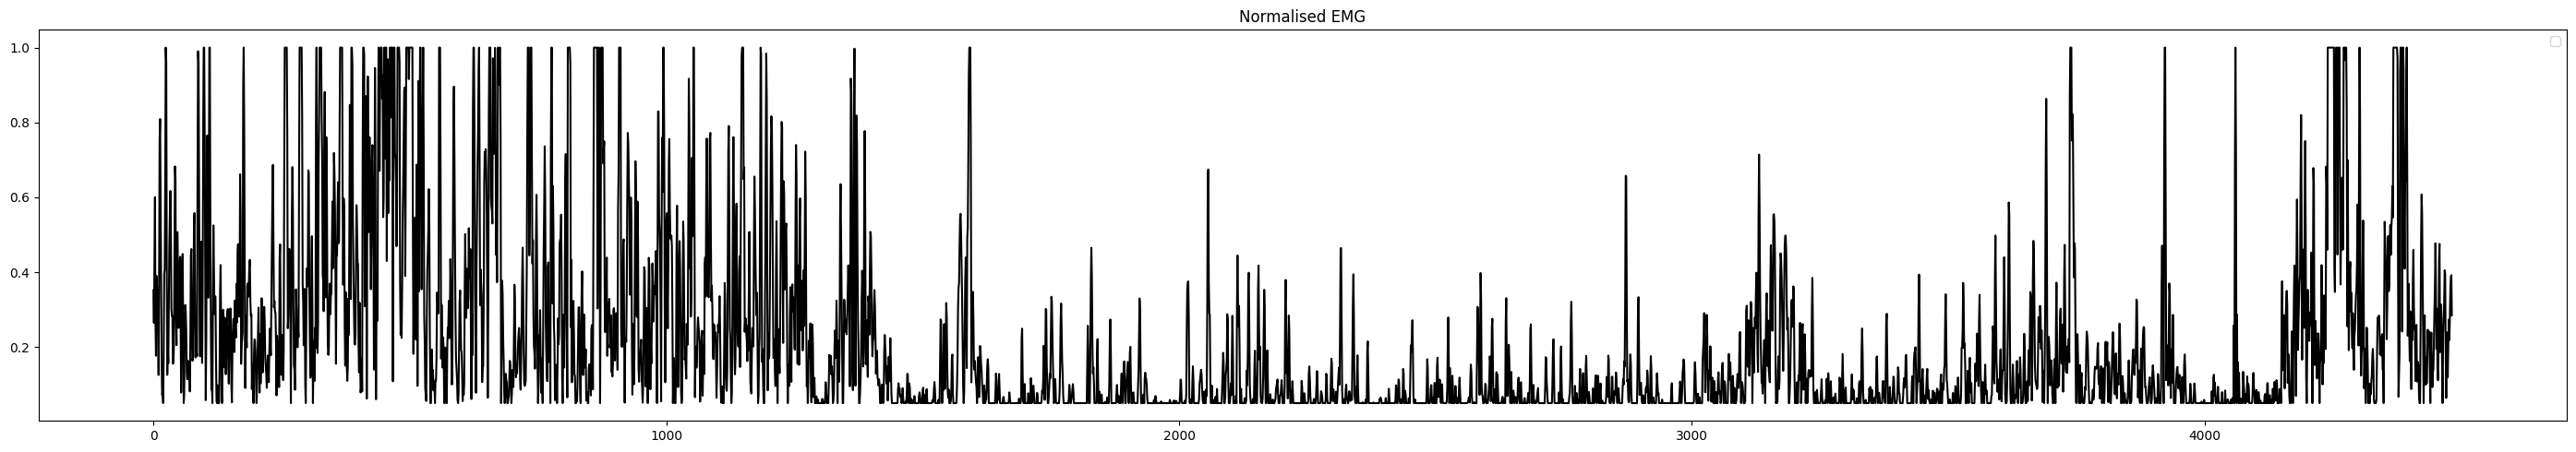

In [115]:

fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 5))

# Plot data on each subplot
ax1.plot(epochs, EMG_norm, label='', color = 'black')

# Add legends
ax1.legend()
ax1.set_title('Normalised EMG')
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/Normalised_EMG.svg", format='svg', dpi=300)
# Show the plots
plt.show()

C:\Users\timmi\AppData\Local\Temp\ipykernel_1952\2752574095.py:22: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.

C:\Users\timmi\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Creating legend with loc="best" can be slow with large amounts of data.



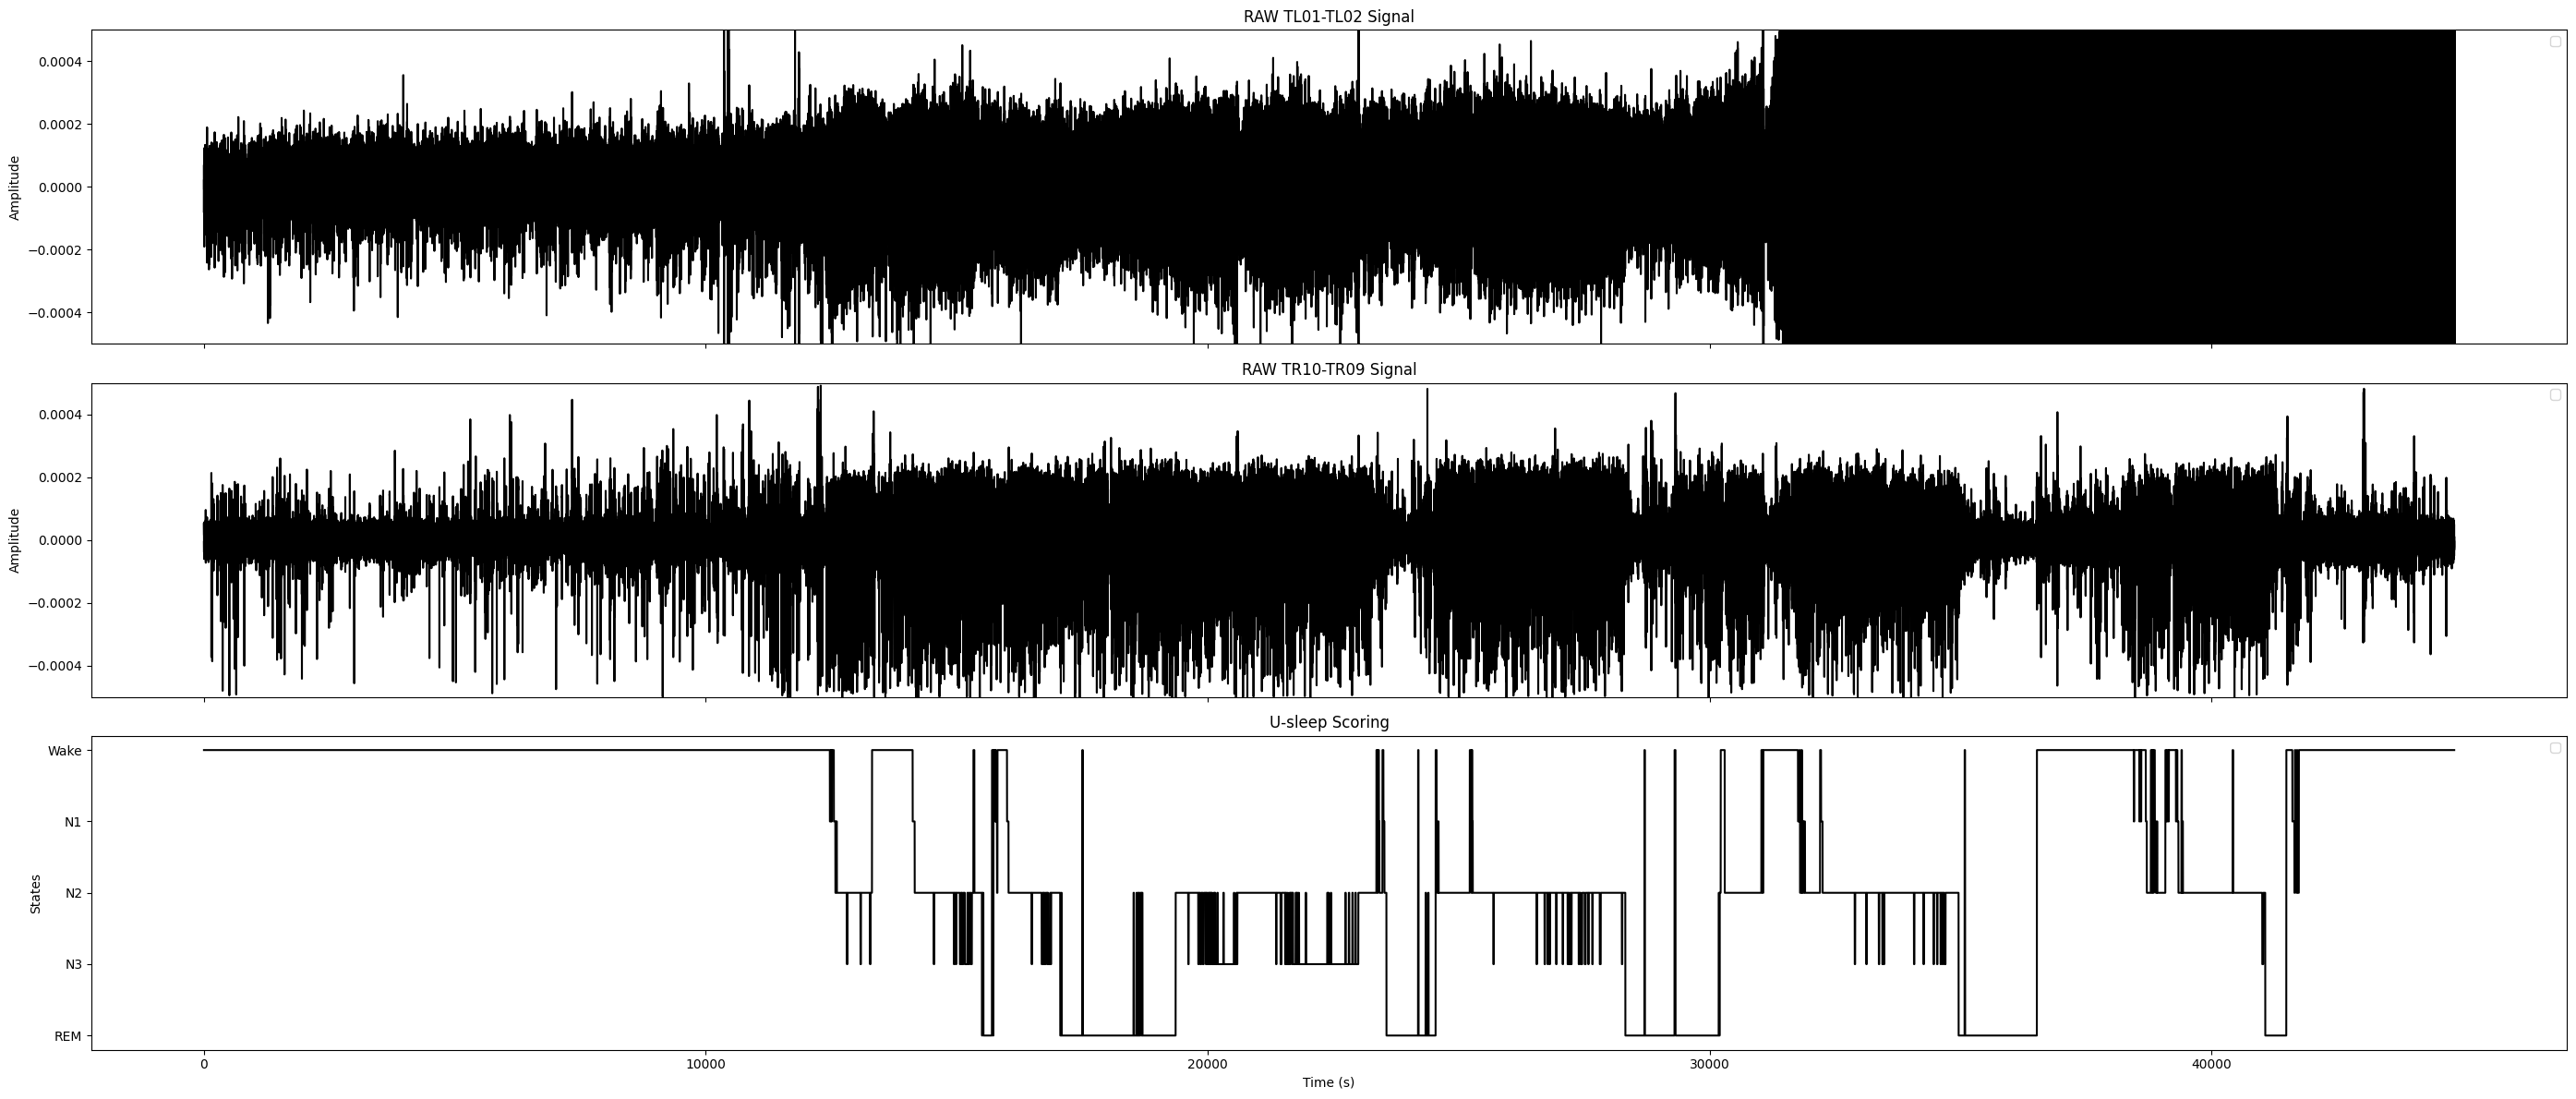

In [116]:
upsampled_states = np.repeat(states, 250 * 10)

target_len = len(raw_hpc)

if len(upsampled_states) < target_len:
    # pad with zeros
    pad_len = target_len - len(upsampled_states)
    upsampled_states = np.concatenate((upsampled_states, np.zeros(pad_len)))
elif len(upsampled_states) > target_len:
    # trim to match
    upsampled_states = upsampled_states[:target_len]
x = np.arange(len(raw_hpc))/250

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize=(28, 12))

# Plot data on each subplot
ax1.plot(x, raw_pfc, label='', color='black')
ax2.plot(x, raw_hpc, label='', color='black')
ax3.plot(x, upsampled_states, label='', color='black')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add axis titles
ax1.set_title(f'RAW {pfc_tag} Signal')
ax2.set_title(f'RAW {hpc_tag} Signal')
ax3.set_title('U-sleep Scoring')

ax1.set_ylabel('Amplitude')
ax2.set_ylabel('Amplitude')
ax3.set_ylabel('States')
ax3.set_xlabel('Time (s)')
state_labels = ['Wake', 'N1', 'N2', 'N3', 'REM']
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 
# Set y-axis limits (example values, adjust as needed)
ax1.set_ylim(-0.0005, 0.0005)  # Replace with appropriate limits for your data
ax2.set_ylim(-0.0005, 0.0005)  # Replace with appropriate limits for your data

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/RAW_signals_Hypnogram.svg", format='svg', dpi=300)
# Show the plots
plt.show()

## Indices

### Wei indexes

#### Get indices

In [117]:
# Raw indices

# rem_features = abs(rem_feature(EOG1, EOG2, epoch_length, fs))
# rem_features = wei_normalizing(rem_features)
# rem_features = np.convolve(np.convolve(np.convolve(rem_features, np.ones(5)/5, mode='same'), np.ones(5)/5,
#                                        mode='same'), np.ones(5)/5, mode='same')
index_w = index_W(delta_norm, gamma_norm, EMG_norm)
index_n = index_N(delta_norm, sigma_norm, gamma_norm)
index_r = index_R(delta_norm, theta_norm, sigma_norm, EMG_norm)
index_1 = Index_1(delta_norm, gamma_norm, EMG_norm)
index_2 = Index_2(delta_norm, theta_norm, sigma_norm)
index_3 = Index_3(delta_norm, theta_norm, gamma_norm)
index_4 = Index_4(delta_norm, theta_norm)

# Taking the log of the indices

index_w_log = np.log(index_w)
index_n_log = np.log(index_n)
index_r_log = np.log(index_r)
index_1_log = np.log(index_1)
index_2_log = np.log(index_2)
index_3_log = np.log(index_3)
index_4_log = np.log(index_4)

# Normalizing the indices

index_w_norm = wei_normalizing(index_w_log)
index_n_norm = wei_normalizing(index_n_log)
index_r_norm = wei_normalizing(index_r_log)
index_1_norm = wei_normalizing(index_1_log)
index_2_norm = wei_normalizing(index_2_log)
index_3_norm = wei_normalizing(index_3_log)
index_4_norm = wei_normalizing(index_4_log)

# Smoothing the indices

index_w_smoothed = np.convolve(np.convolve(np.convolve(index_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_n_smoothed = np.convolve(np.convolve(np.convolve(index_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_r_smoothed = np.convolve(np.convolve(np.convolve(index_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_1_smoothed = np.convolve(np.convolve(np.convolve(index_1_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_2_smoothed = np.convolve(np.convolve(np.convolve(index_2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_3_smoothed = np.convolve(np.convolve(np.convolve(index_3_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
index_4_smoothed = np.convolve(np.convolve(np.convolve(index_4_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')



#### Save wei features matrix

In [118]:
wei_features = np.column_stack((index_w_smoothed, index_n_smoothed, index_r_smoothed, index_1_smoothed, index_2_smoothed, index_3_smoothed, index_4_smoothed, noise_smoothed, theta_smoothed, delta_smoothed))
#np.save('Wei_features.npy', wei_features)

In [119]:
print(mapped_scores)

[0 0 0 ... 0 0 0]


#### Main indices plots

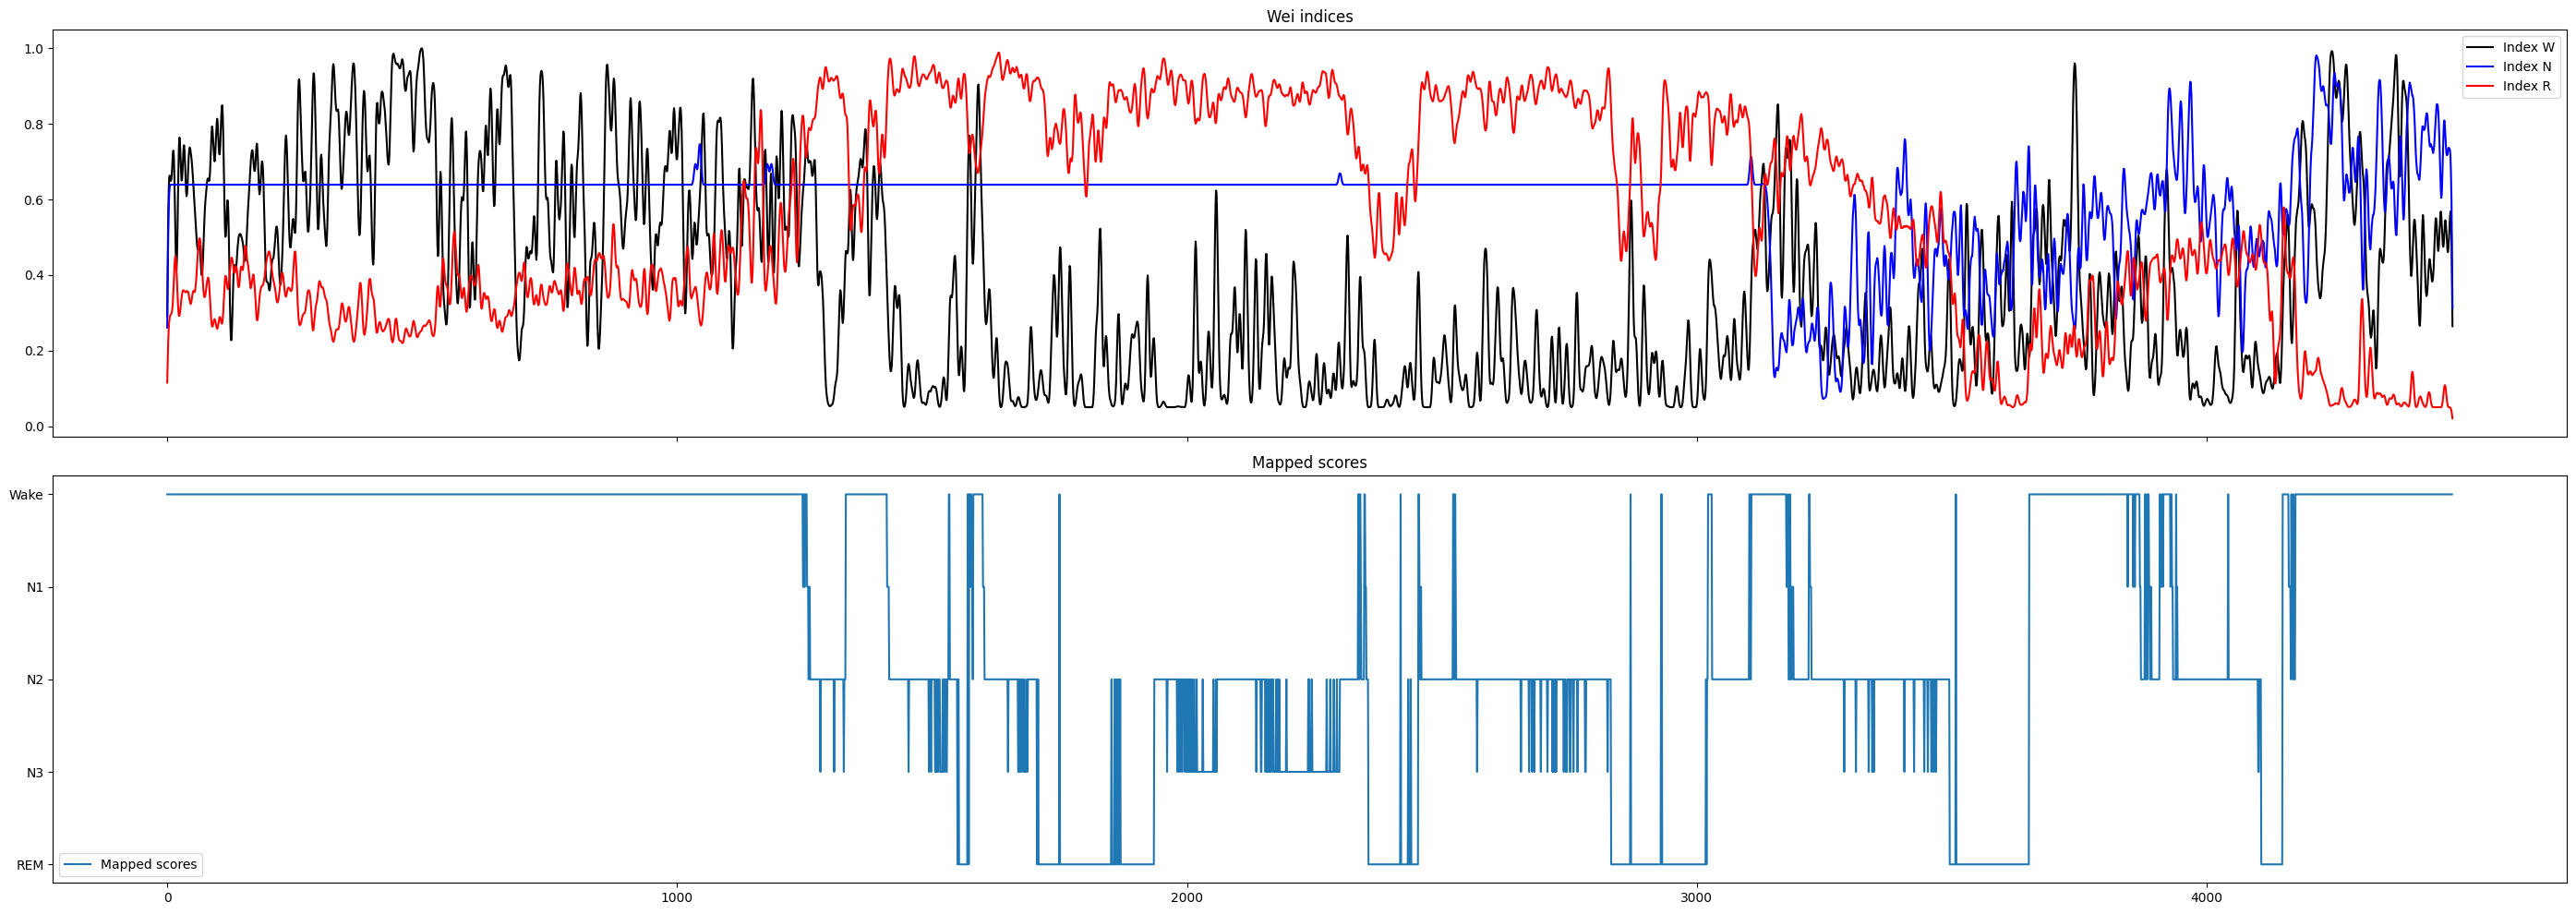

In [120]:
# All main indices

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 10))
# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color='red')

ax2.plot(hypno_epochs, mapped_scores, label='Mapped scores')


# Add legends
ax1.legend()
ax2.legend()


# Add titles
ax1.set_title('Wei indices')
ax2.set_title('Mapped scores')
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/Wei_indices_original.svg", format='svg')
# Show the plots
plt.show()

### New indexes

#### New WAKE (define and get index)

##### Compute new index + function

In [121]:
nindex_w = nindex_W(theta_norm, gamma_norm, EMG_norm)
nindex_w_log = np.log(nindex_w)
nindex_w_norm = wei_normalizing(nindex_w_log)
nindex_w_smoothed = np.convolve(np.convolve(np.convolve(nindex_w_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

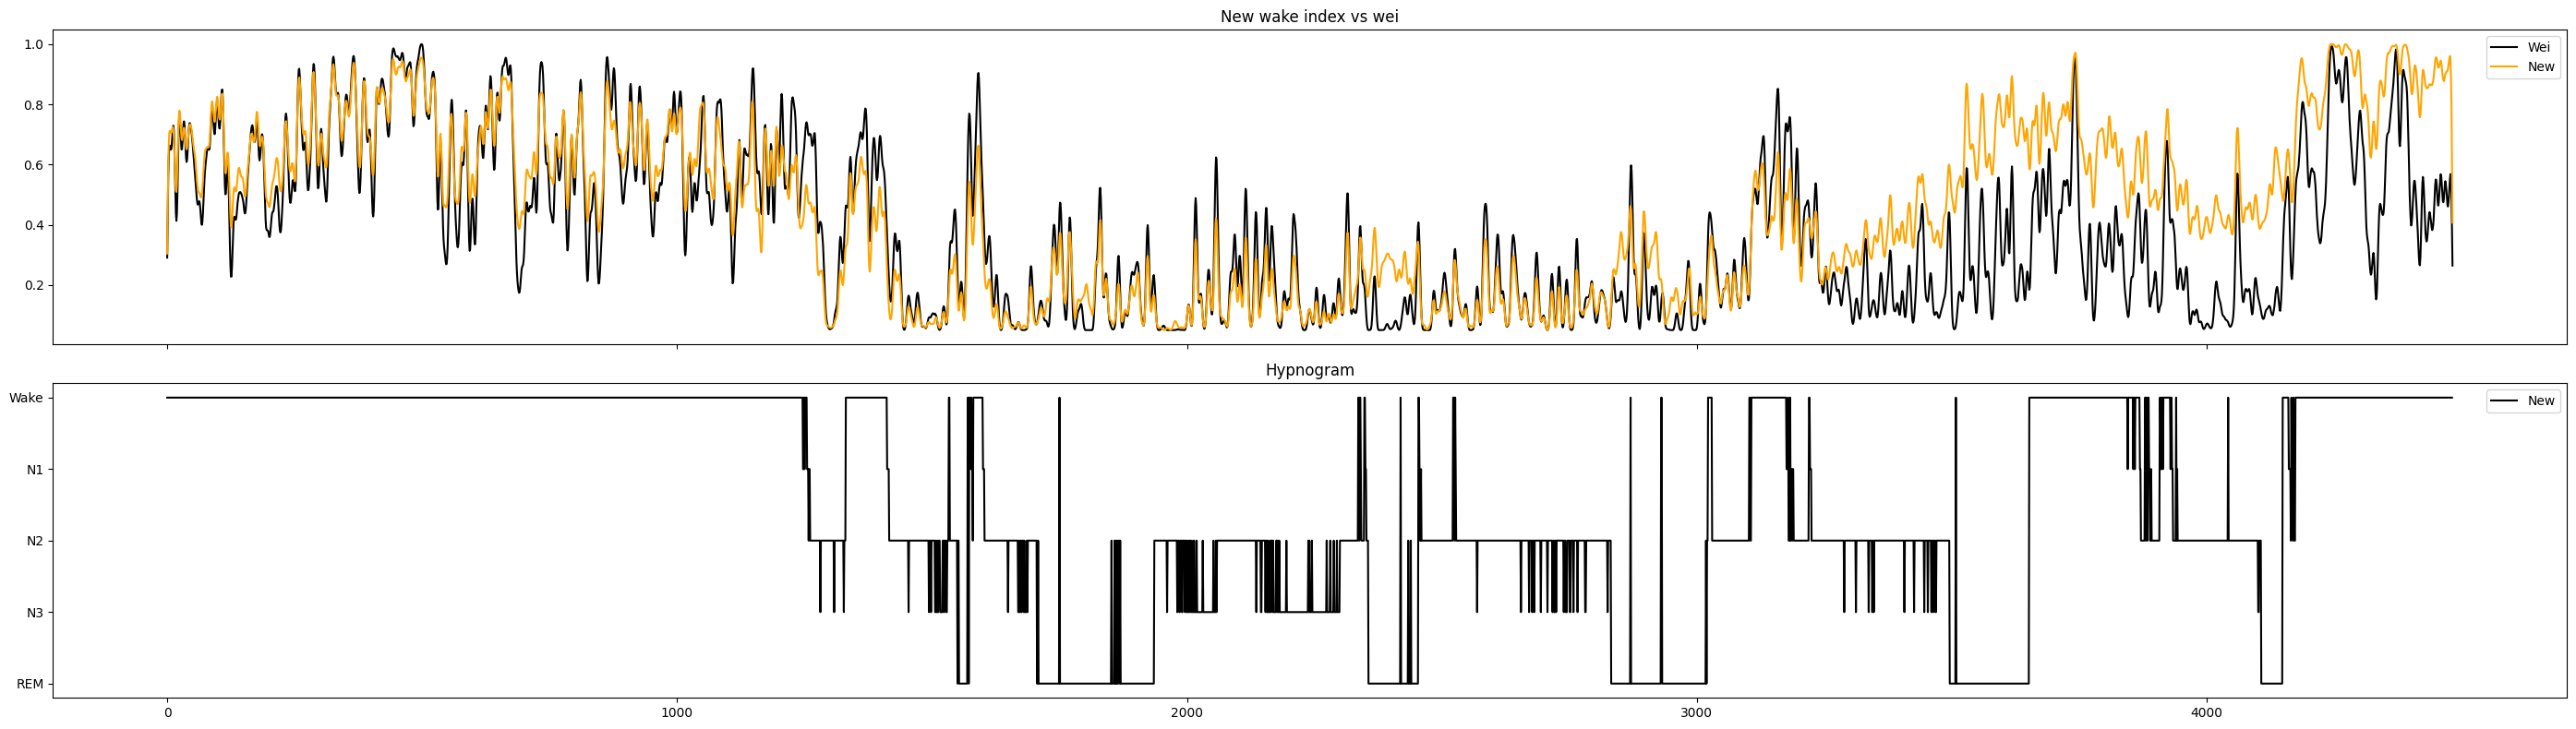

In [122]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_w_smoothed, label='New', color = 'orange')
ax2.plot(hypno_epochs, mapped_scores, label='New', color = 'black')

ax1.set_title("New wake index vs wei")
ax2.set_title("Hypnogram")
# Add legends
ax1.legend()
ax2.legend()
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/new_wake_index_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### All indices plot

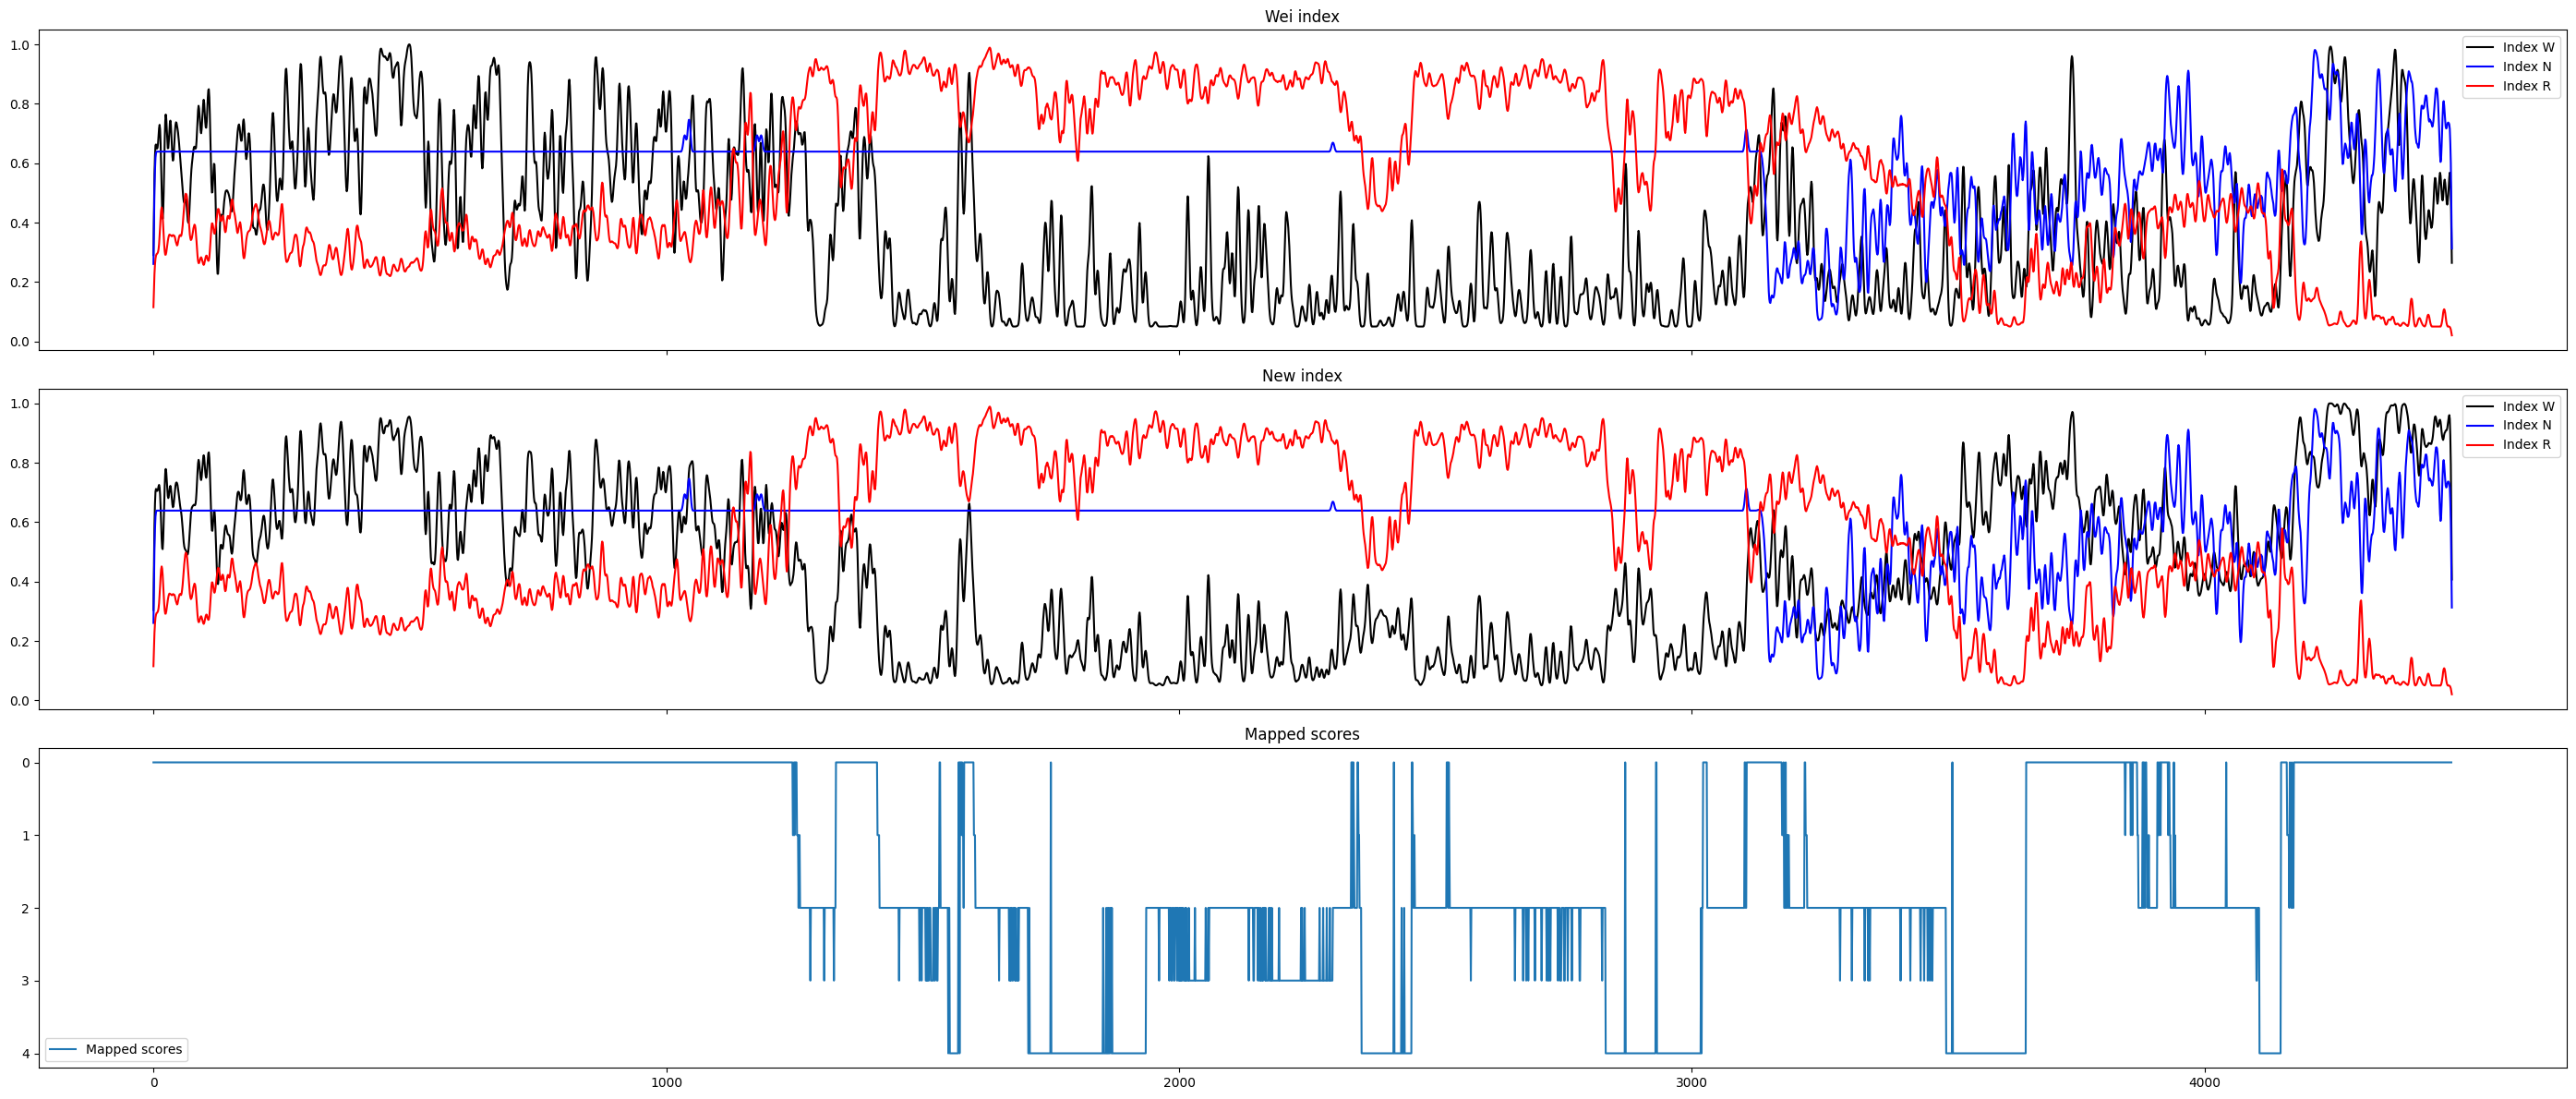

In [123]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, nindex_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')


ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')

ax3.set_yticks([0, 1, 2, 3, 4])
# ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/all_indices_new_wake_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [124]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
score_labels = {0: 'Wake', 1: 'N1', 2: 'N2', 3: 'N3', 4: 'REM'}
mapped_scores_old = mapped_scores
mapped_scores = [score_labels[s] for s in mapped_scores]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):
  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(nindex_w_smoothed[i])
    nindex_n1[1].append(index_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(nindex_w_smoothed[i])
    nindex_n2[1].append(index_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(nindex_w_smoothed[i])
    nindex_n3[1].append(index_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [125]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

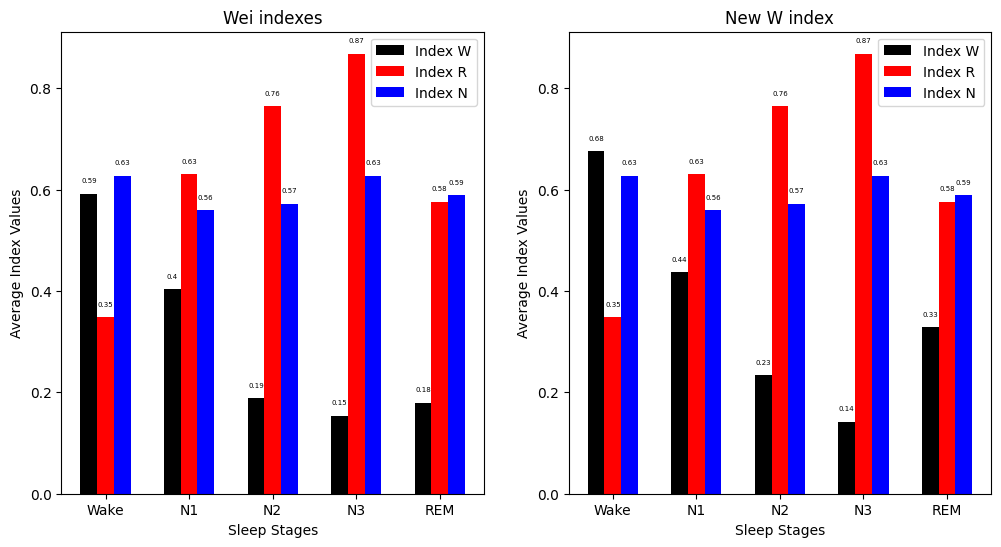

In [126]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

fontsize = 5

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New W index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
plt.savefig(f"{output_dir}/wei_new_wake_barplot.svg", format='svg')

#### New REM (define and get index)

##### Compute new index + function

In [127]:
nindex_r = nindex_R(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
nindex_r_log = np.log(nindex_r)
nindex_r_norm = wei_normalizing(nindex_r_log)
nindex_r_smoothed = np.convolve(np.convolve(np.convolve(nindex_r_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')
# nindex_r_smoothed_n = np.mean(np.stack([nindex_r_smoothed, rem_features]), axis=0)
# nindex_r_smoothed_n = spike_conflict_avg(nindex_r_smoothed, rem_features)

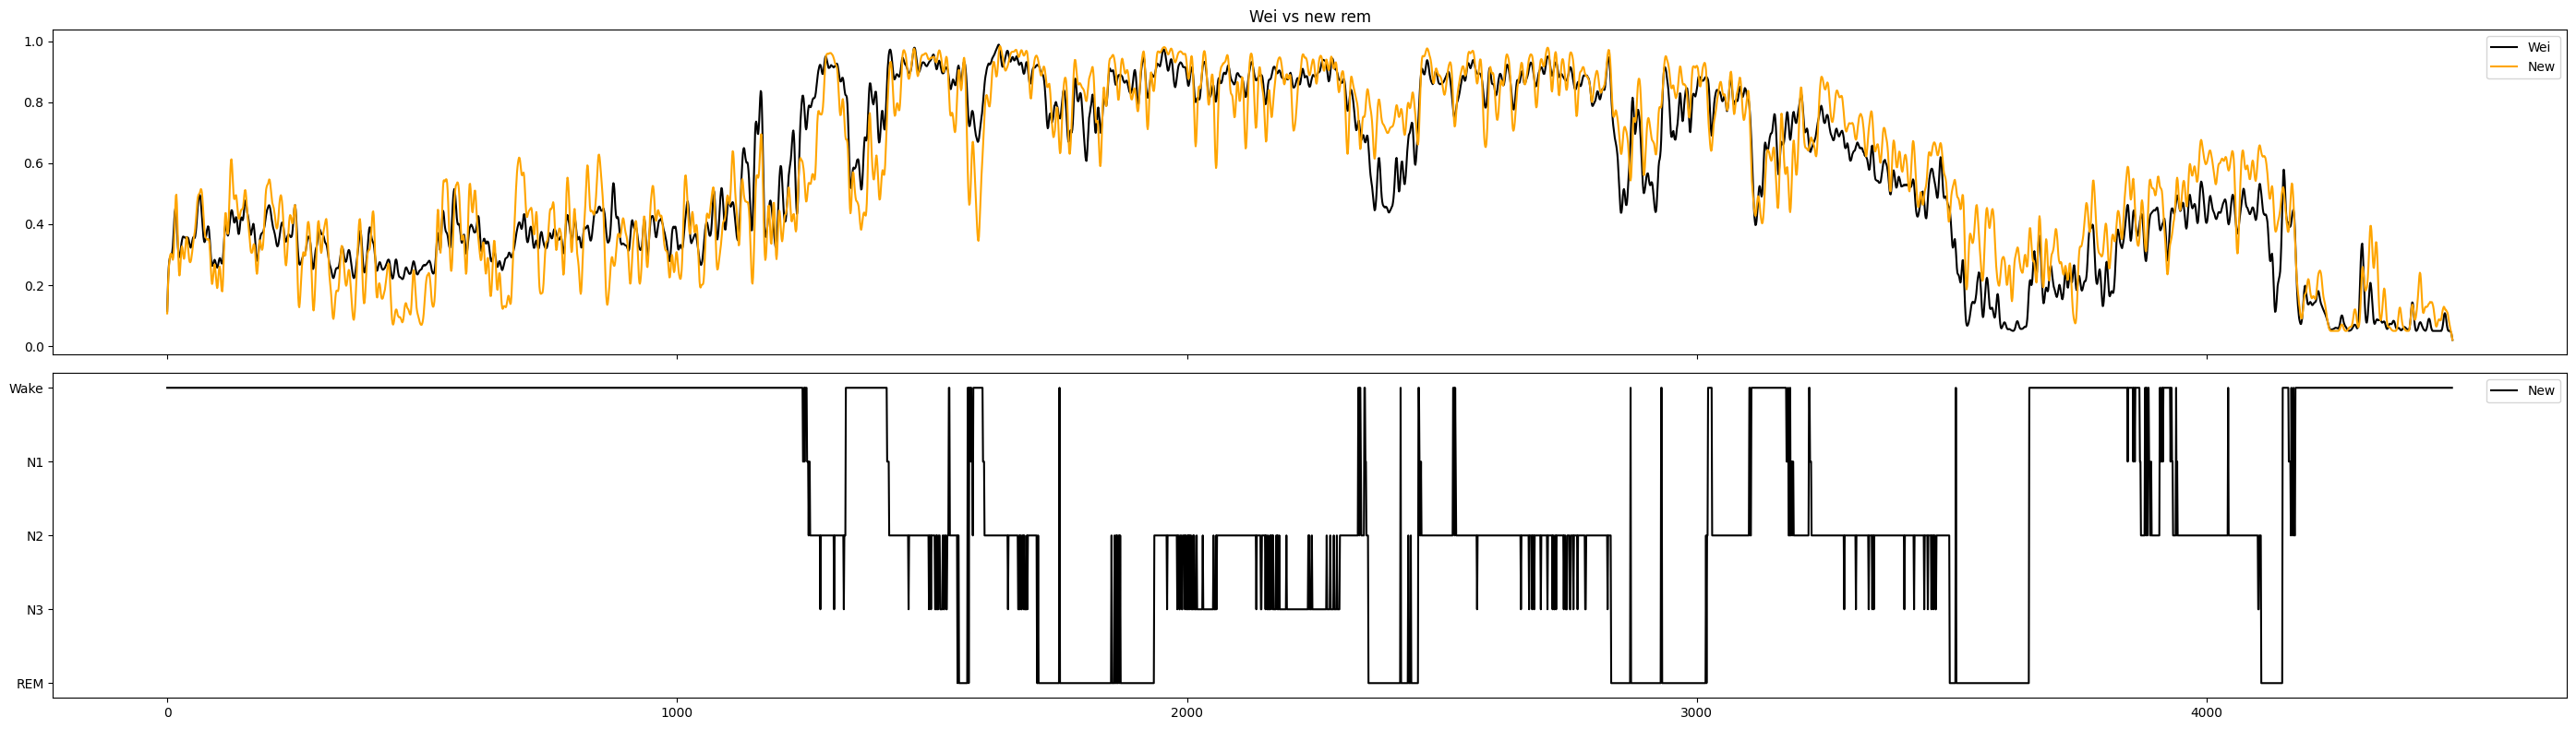

In [128]:
fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_r_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_r_smoothed, label='New', color = 'orange')
ax2.plot(hypno_epochs, mapped_scores, label='New', color = 'black')
ax1.set_title("Wei vs new rem")
# Add legends
ax1.legend()
ax2.legend()
ax2.set_yticks([0, 1, 2, 3, 4])
ax2.set_yticklabels(state_labels)
ax2.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/new_rem_vs_wei.svg", format='svg')
# Show the plots
plt.show()

##### All indices plot

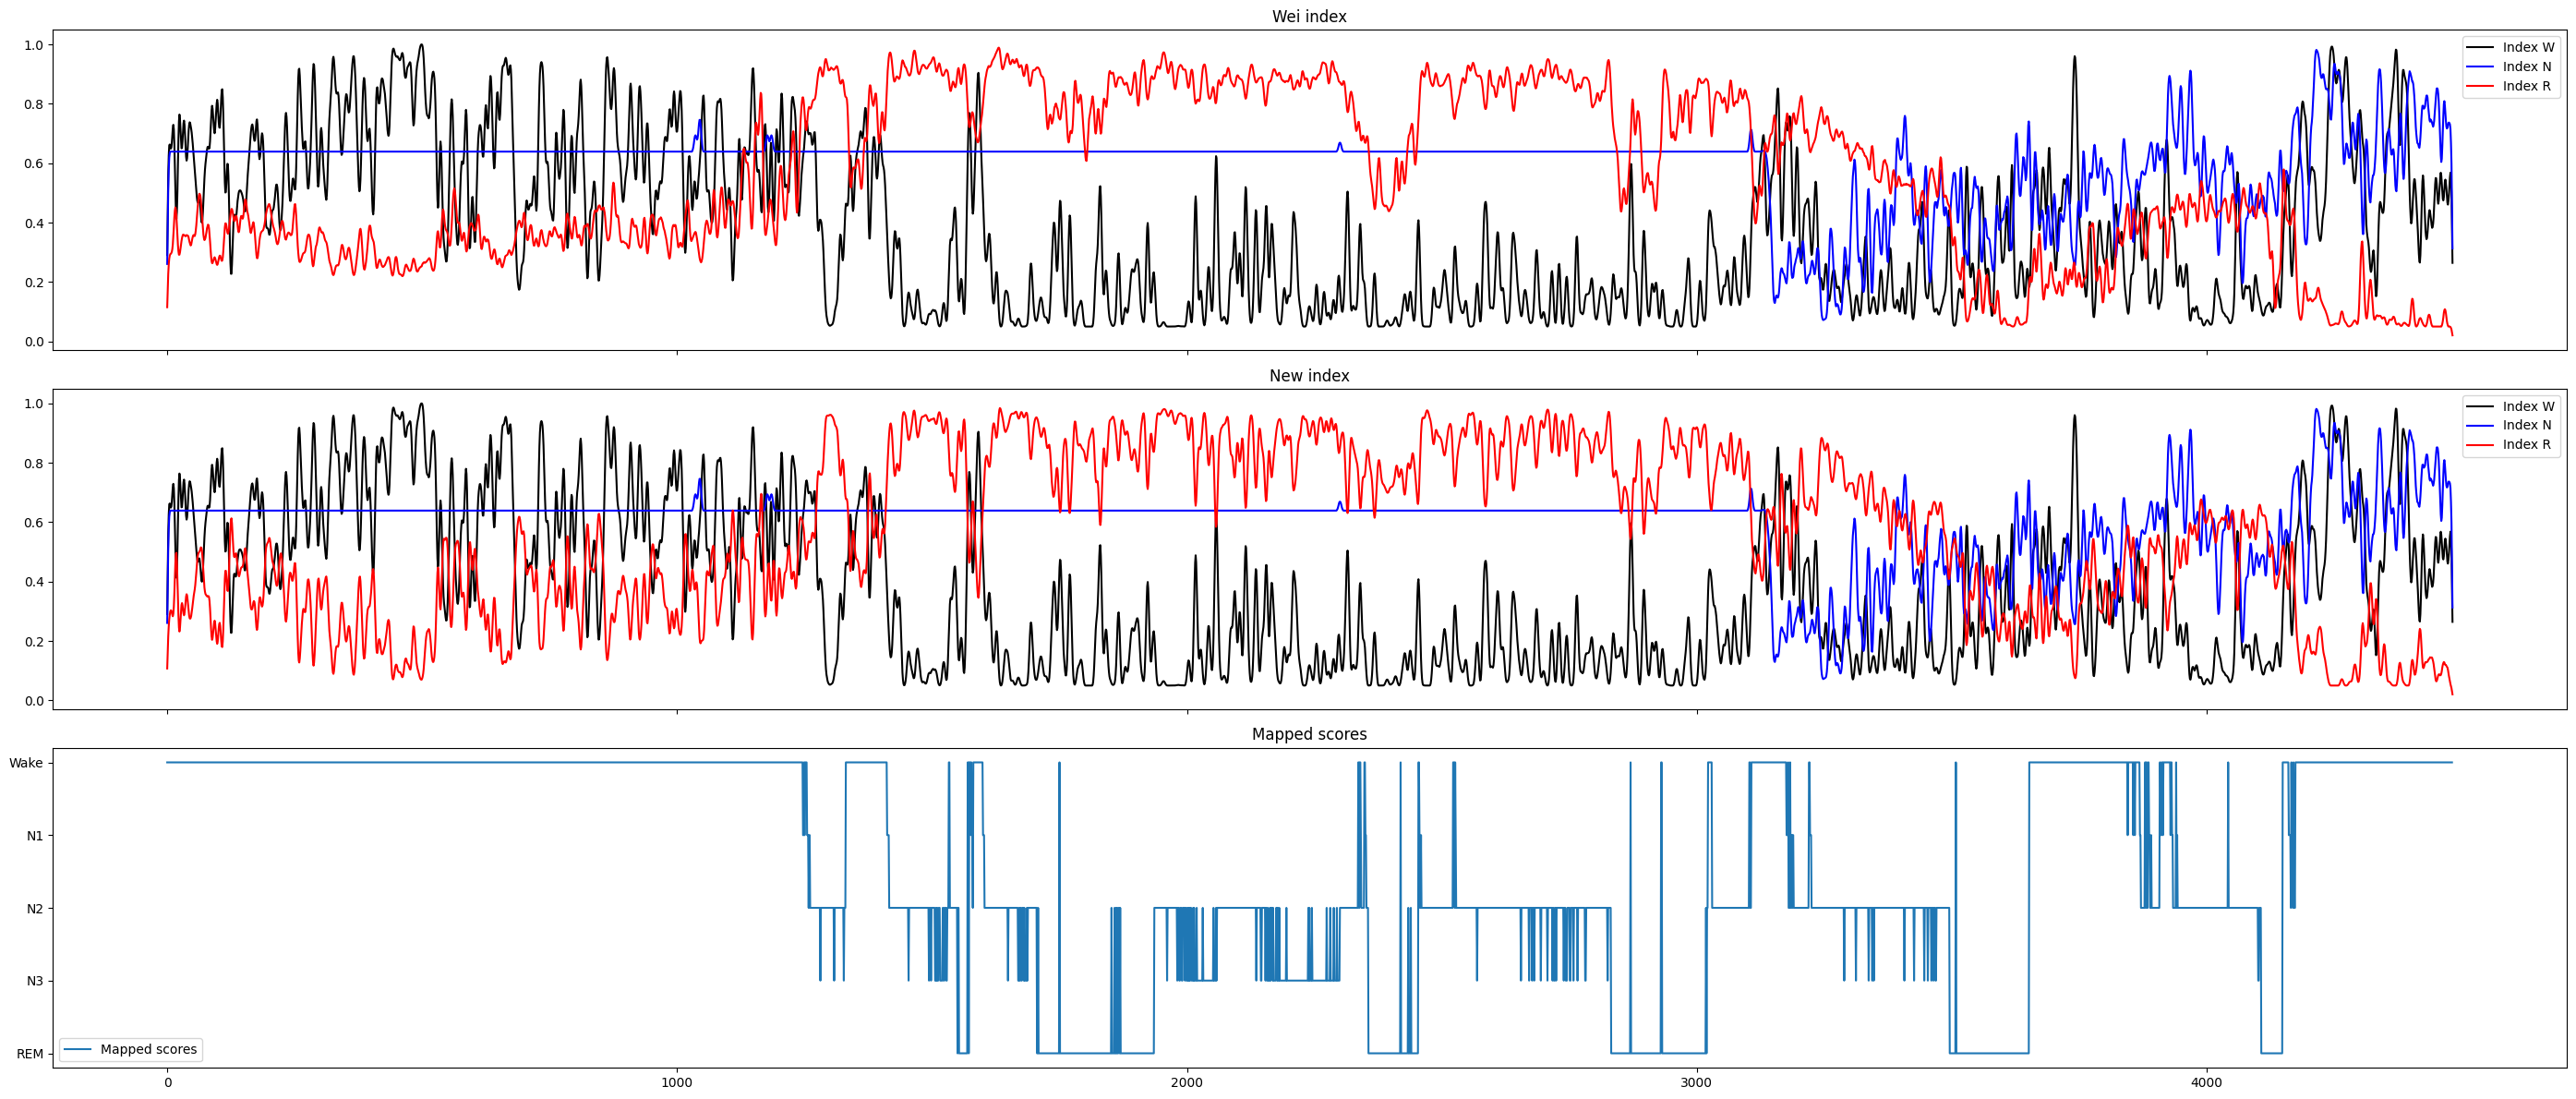

In [129]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, nindex_r_smoothed, label='Index R', color ='red')


ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis() 
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/wei_vs_new_rem_all_indices.svg", format='svg')
# Show the plots
plt.show()

##### Barplots

###### Prerequisites

In [130]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])
# New
nindex_Wake = [[],[],[]]
nindex_NREM = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])
  elif el == 'N1':
    nindex_n1[0].append(index_w_smoothed[i])
    nindex_n1[1].append(nindex_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(index_w_smoothed[i])
    nindex_n2[1].append(nindex_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(index_w_smoothed[i])
    nindex_n3[1].append(nindex_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [131]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

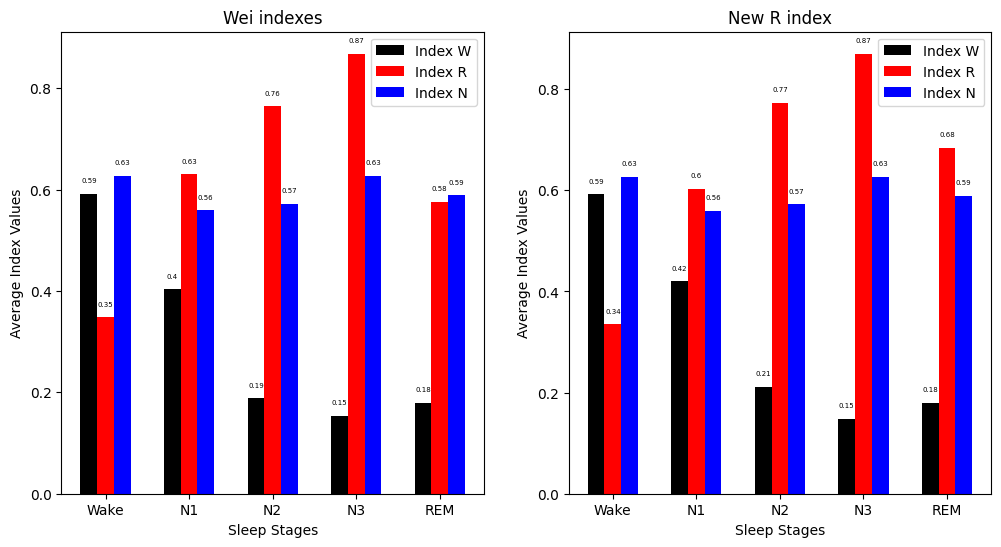

In [132]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]

x = np.arange(len(categories))
bar_width = 0.2
fontsize = 5
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New R index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    
plt.savefig(f"{output_dir}/new_rem_vs_wei_bar.svg", format='svg', dpi=300)

#### New NREM (define and get index)

##### Compute new index + function

In [133]:
nindex_n = nindex_N(delta_norm, sigma_norm, gamma_norm)
nindex_n_log = np.log(nindex_n)
nindex_n_norm = wei_normalizing(nindex_n_log)
nindex_n_smoothed = np.convolve(np.convolve(np.convolve(nindex_n_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

In [134]:
nindex_n2 = nindex_N2(delta_norm, theta_norm, sigma_norm, EMG_norm, gamma_norm)
nindex_n2_log = np.log(nindex_n2)
nindex_n2_norm = wei_normalizing(nindex_n2_log)
nindex_n2_smoothed = np.convolve(np.convolve(np.convolve(nindex_n2_norm, np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same'), np.ones(5)/5, mode='same')

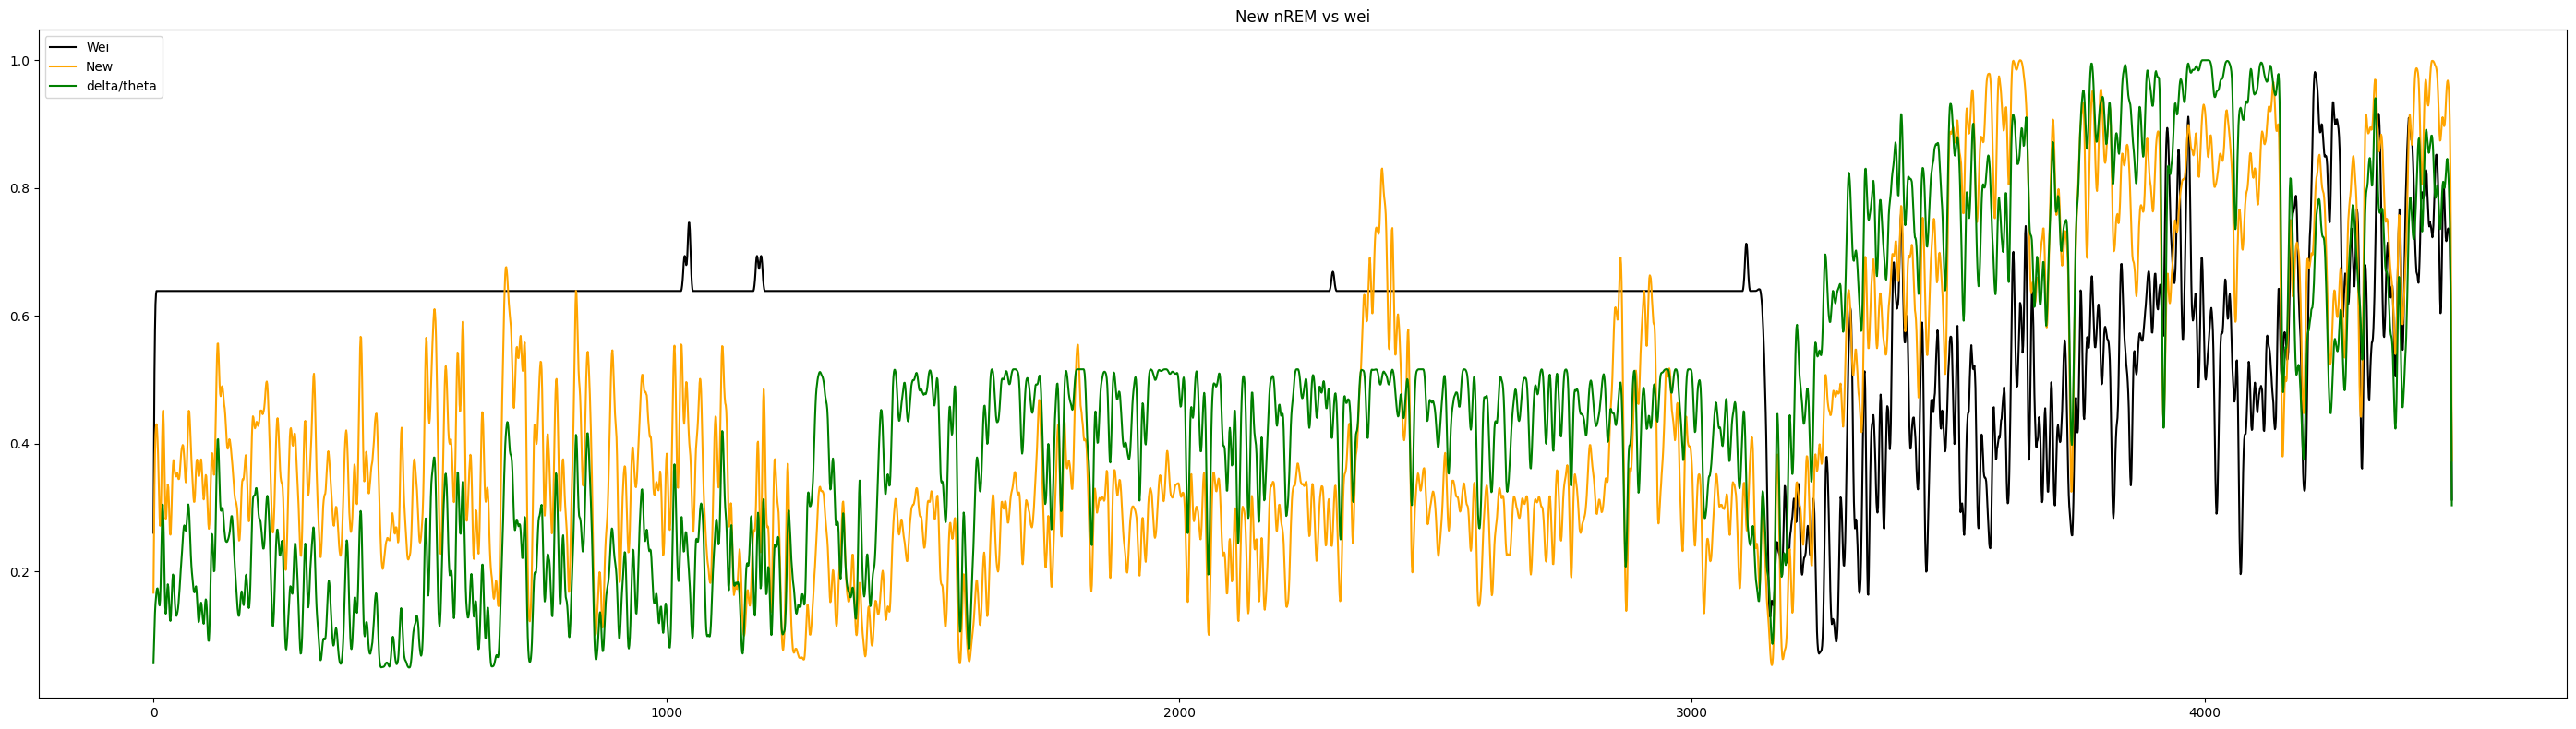

In [135]:
fig, (ax1) = plt.subplots(1, 1, sharex=True, figsize = (28, 8))

# Plot data on each subplot
ax1.plot(epochs, index_n_smoothed, label='Wei', color = 'black')
ax1.plot(epochs, nindex_n_smoothed, label='New', color = 'orange')
ax1.plot(epochs, nindex_n2_smoothed, label='delta/theta', color = 'green')
ax1.set_title("New nREM vs wei")
# Add legendsg
ax1.legend()

# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/new_index_n_vs_wei.svg", format='svg', dpi=300)
# Show the plots
plt.show()

##### All indices plot

Amount of indices: 4483


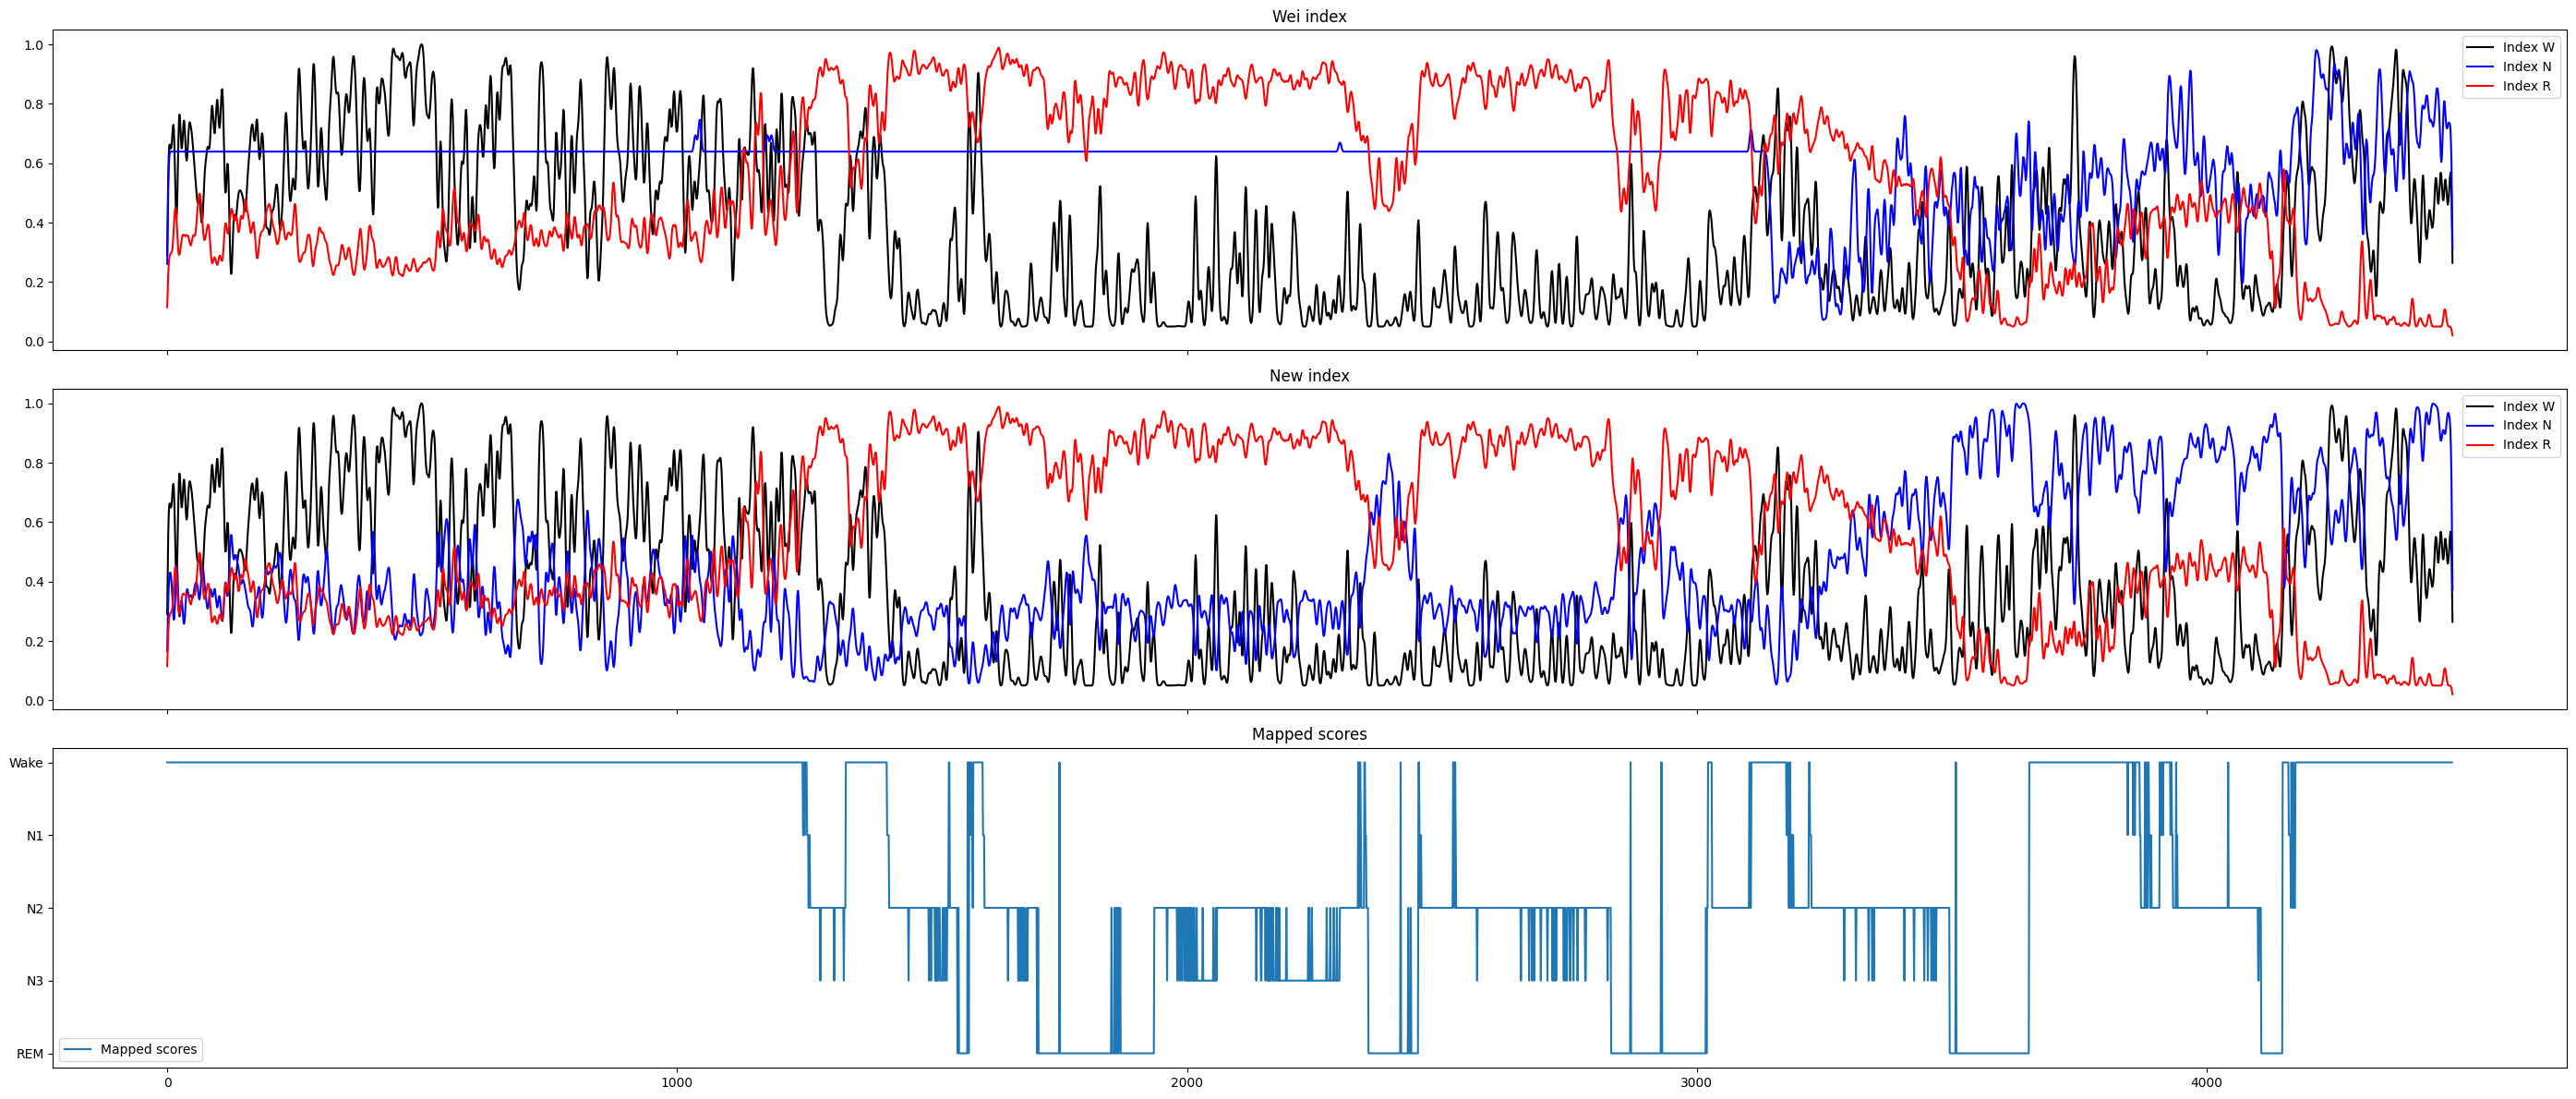

In [136]:
# All indices smoothed for better visualisation

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 12))

# Plot data on each subplot
ax1.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax1.plot(epochs, index_n_smoothed, label='Index N', color ='blue')
ax1.plot(epochs, index_r_smoothed, label='Index R', color ='red')

ax2.plot(epochs, index_w_smoothed, label='Index W', color ='black')
ax2.plot(epochs, nindex_n_smoothed, label='Index N', color ='blue')
ax2.plot(epochs, index_r_smoothed, label='Index R', color ='red')

print(f"Amount of indices: {len(index_w_smoothed)}")

ax3.plot(hypno_epochs, mapped_scores, label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei index')
ax2.set_title('New index')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f"{output_dir}/all_indices_nrem_vs_wei.svg", format='svg', dpi=300)
# Show the plots
plt.show()

##### Barplots

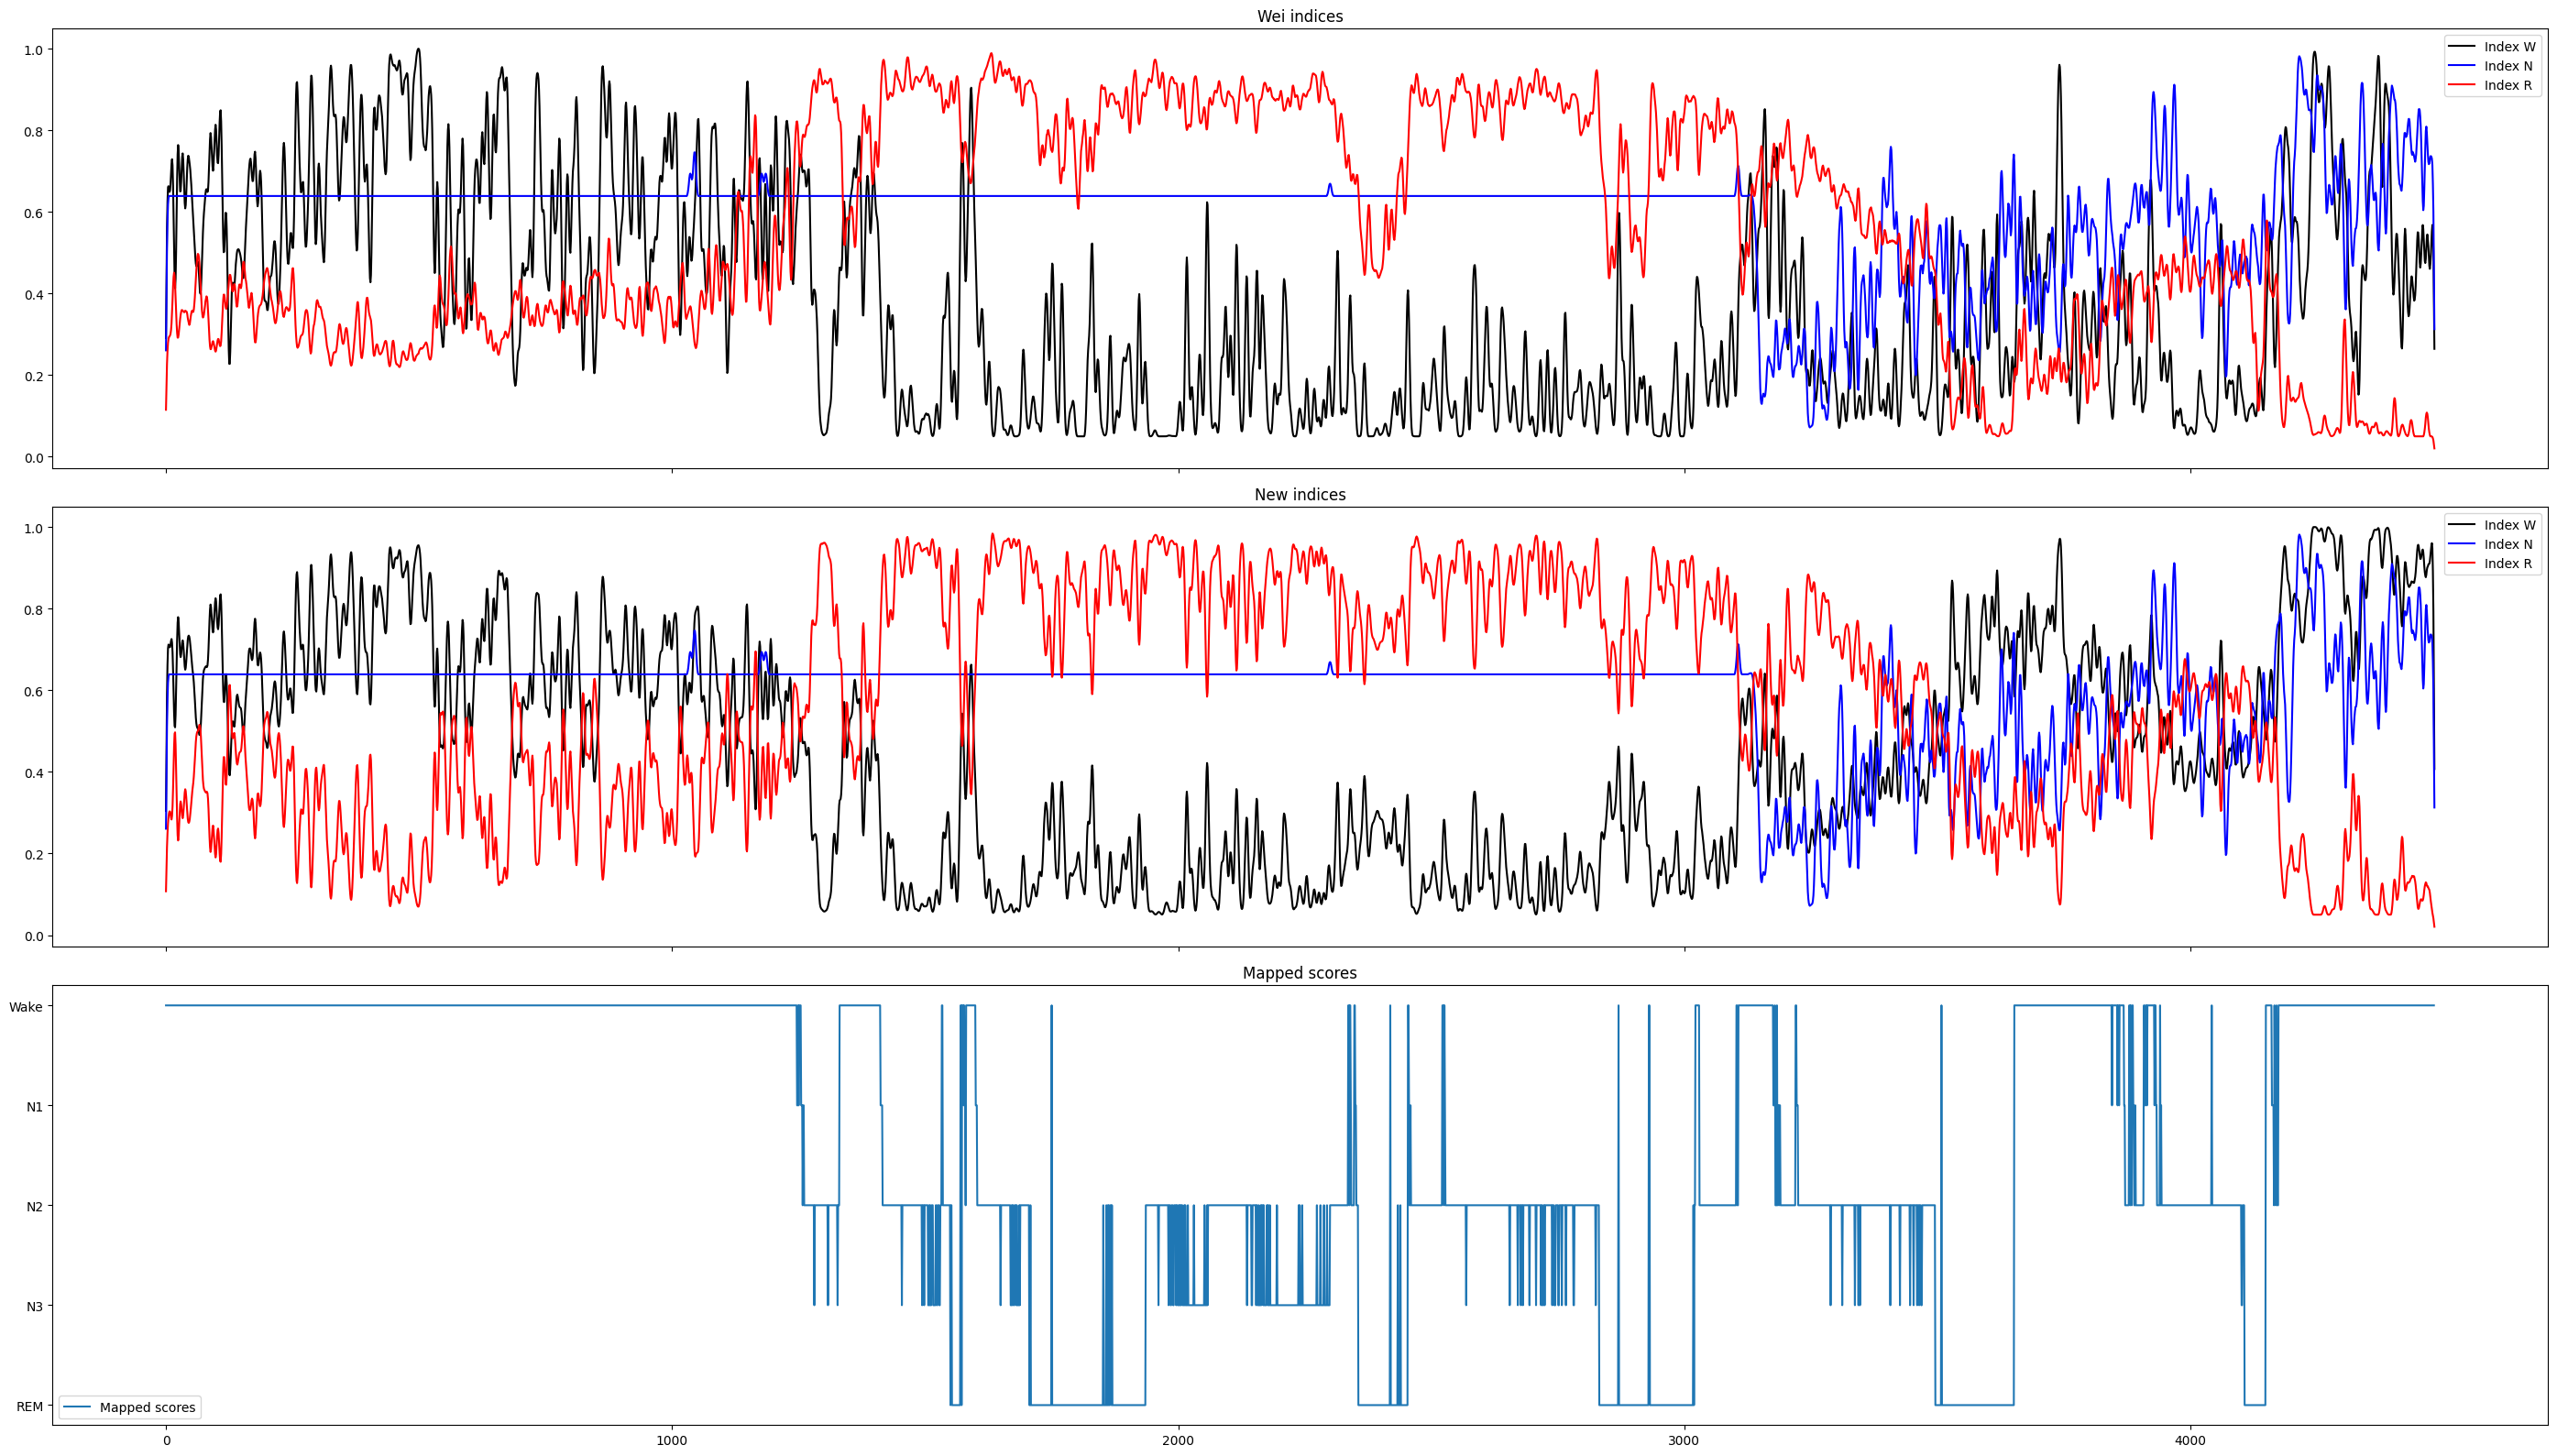

In [137]:
# All main indices
times = np.arange(0, len(epochs))
hypno_times = np.arange(0, len(hypno_epochs))
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 16))

# Plot data on each subplot
ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')

ax2.plot(epochs[times], nindex_w_smoothed[times], label='Index W', color='black')
ax2.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
ax2.plot(epochs[times], nindex_r_smoothed[times], label='Index R', color='red')

ax3.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')

# Add legends
ax1.legend()
ax2.legend()
ax3.legend()

# Add titles
ax1.set_title('Wei indices')
ax2.set_title('New indices')
ax3.set_title('Mapped scores')
ax3.set_yticks([0, 1, 2, 3, 4])
ax3.set_yticklabels(state_labels)
ax3.invert_yaxis()
# Adjust layout to avoid overlap
plt.tight_layout()
plt.savefig(f'{output_dir}/all_new_indices_vs_wei.svg', format='svg')
# Show the plots
plt.show()

In [138]:
# times = np.arange(0, len(epochs))
# hypno_times = np.arange(0, len(hypno_epochs))
# fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, sharex=True, figsize = (28, 16))
# 
# # Plot data on each subplot
# ax1.plot(epochs[times], index_r_smoothed[times], label='Old Index R', color='blue')
# 
# # ax2.plot(epochs[times], rem_features[times], label="EOG feature", color='orange')
# 
# # ax3.plot(epochs[times], nindex_r_smoothed_n[times], label='Combined & averaged index', color='black')
# 
# ax4.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')
# 
# # Add legends
# ax1.legend()
# ax2.legend()
# ax3.legend()
# ax4.legend()
# 
# # Add titles
# ax1.set_title('Old R index')
# # ax2.set_title('EOG feature')
# ax3.set_title('Combined & averaged feature')
# ax4.set_title('Mapped scores')
# ax1.set_ylim(0,1)
# ax2.set_ylim(0,1)
# ax3.set_ylim(0,1)
# ax4.set_yticks([0, 1, 2, 3, 4])
# ax4.set_yticklabels(state_labels)
# ax4.invert_yaxis()
# # Adjust layout to avoid overlap
# ax1.grid(True)
# ax2.grid(True)
# ax3.grid(True)
# ax4.grid(True)
# plt.tight_layout()
# plt.savefig(f'{output_dir}/feature_comparison_rem.svg', format='svg')
# # Show the plots
# plt.show()

In [139]:
# times = np.arange(0, len(epochs))
# hypno_times = np.arange(0, len(hypno_epochs))
# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize = (40, 16))
# 
# # Plot data on each subplot
# ax1.plot(epochs[times], index_r_smoothed[times], label='Old Index R', color='blue')
# 
# # ax1.plot(epochs[times], rem_features[times], label="EOG feature", color='orange')
# 
# # ax1.plot(epochs[times], nindex_r_smoothed_n[times], label='Combined & averaged index', color='black')
# 
# ax2.plot(hypno_epochs[hypno_times], mapped_scores_old[hypno_times], label='Mapped scores')
# 
# # Add legends
# ax1.legend()
# ax2.legend()
# ax1.set_ylim(0,1)
# ax1.grid(True)
# 
# ax1.set_title('All features comparison')
# ax2.set_title('Mapped scores')
# ax2.set_yticks([0, 1, 2, 3, 4])
# ax2.set_yticklabels(state_labels)
# ax2.invert_yaxis()
# # Adjust layout to avoid overlap
# plt.tight_layout()
# plt.savefig('feature_comparison_rem_1plot.svg', format='svg')
# # Show the plots
# plt.show()

###### Prerequisites

In [140]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3 = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(index_w_smoothed[i])
    nindex_Wake[1].append(index_r_smoothed[i])
    nindex_Wake[2].append(nindex_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(index_w_smoothed[i])
    nindex_n1[1].append(index_r_smoothed[i])
    nindex_n1[2].append(nindex_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(index_w_smoothed[i])
    nindex_n2[1].append(index_r_smoothed[i])
    nindex_n2[2].append(nindex_n_smoothed[i])
  elif el =='N3':
    nindex_n3[0].append(index_w_smoothed[i])
    nindex_n3[1].append(index_r_smoothed[i])
    nindex_n3[2].append(nindex_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(index_w_smoothed[i])
    nindex_REM[1].append(index_r_smoothed[i])
    nindex_REM[2].append(nindex_n_smoothed[i])

In [141]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

###### Barplots

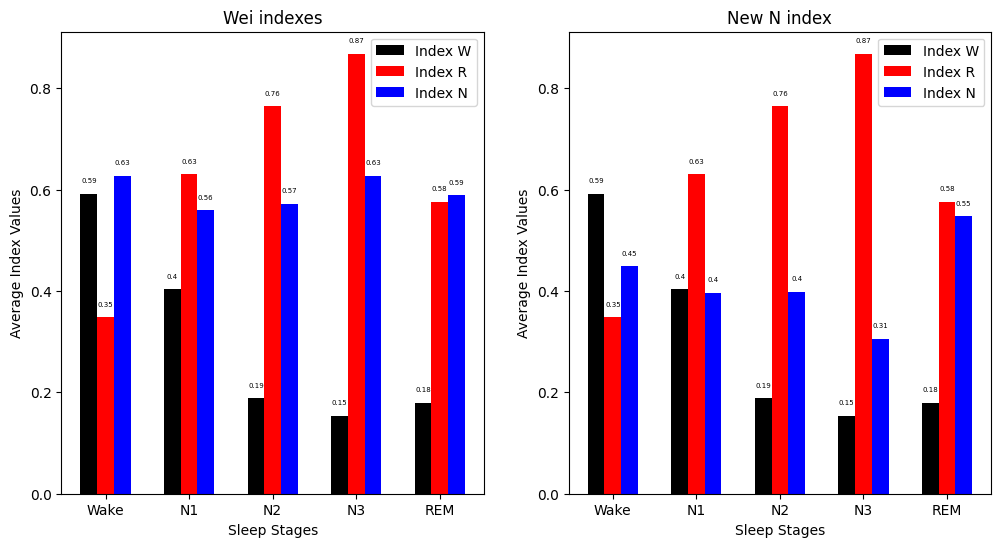

In [142]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indexes')
plt.xticks(x, categories)
plt.legend()
fontsize = 5
for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, REM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red')
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New N index')
plt.xticks(x, categories)
plt.legend()

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)

plt.savefig(f"{output_dir}/wei_vs_new_n_barplot.svg", format='svg')

### Comparing Wei vs New

#### Plot

In [143]:
# # All main indices
# times = np.arange(3000, 3500)
# fig, (ax1, ax2, ax3) = plt.subplots(3, 1, sharex=True, figsize = (28, 16))
# 
# # Plot data on each subplot
# ax1.plot(epochs[times], index_w_smoothed[times], label='Index W', color='black')
# ax1.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
# ax1.plot(epochs[times], index_r_smoothed[times], label='Index R', color='red')
# 
# ax2.plot(epochs[times], nindex_w_smoothed[times], label='Index W', color='black')
# ax2.plot(epochs[times], index_n_smoothed[times], label='Index N', color='blue')
# ax2.plot(epochs[times], nindex_r_smoothed[times], label='Index R', color='red')
# 
# ax3.plot(hypno_epochs[times], mapped_scores_old[times], label='Mapped scores')
# 
# # Add legends
# ax1.legend()
# ax2.legend()
# ax3.legend()
# 
# # Add titles
# ax1.set_title('Wei indices')
# ax2.set_title('New indices')
# ax3.set_title('Mapped scores')
# ax3.set_yticks([0, 1, 2, 3, 4])
# ax3.set_yticklabels(state_labels)
# ax3.invert_yaxis()
# # Adjust layout to avoid overlap
# plt.tight_layout()
# # Show the plots
# plt.savefig(f"{output_dir}/all_new_indices_vs_wei_closeup.svg", format='svg', dpi=300)
# plt.show()

###### Prerequisites

In [144]:
# Wei
index_Wake = [[],[],[]]
index_n1 = [[],[],[]]
index_n2 = [[],[],[]]
index_n3 = [[],[],[]]
index_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    index_Wake[0].append(index_w_smoothed[i])
    index_Wake[1].append(index_r_smoothed[i])
    index_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    index_n1[0].append(index_w_smoothed[i])
    index_n1[1].append(index_r_smoothed[i])
    index_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    index_n2[0].append(index_w_smoothed[i])
    index_n2[1].append(index_r_smoothed[i])
    index_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    index_n3[0].append(index_w_smoothed[i])
    index_n3[1].append(index_r_smoothed[i])
    index_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    index_REM[0].append(index_w_smoothed[i])
    index_REM[1].append(index_r_smoothed[i])
    index_REM[2].append(index_n_smoothed[i])

# New
nindex_Wake = [[],[],[]]
nindex_n1 = [[],[],[]]
nindex_n2 = [[],[],[]]
nindex_n3  = [[],[],[]]
nindex_REM = [[],[],[]]
for i, el in enumerate(mapped_scores):

  if el == 'Wake':
    nindex_Wake[0].append(nindex_w_smoothed[i])
    nindex_Wake[1].append(nindex_r_smoothed[i])
    nindex_Wake[2].append(index_n_smoothed[i])

  elif el == 'N1':
    nindex_n1[0].append(nindex_w_smoothed[i])
    nindex_n1[1].append(nindex_r_smoothed[i])
    nindex_n1[2].append(index_n_smoothed[i])
  elif el == 'N2':
    nindex_n2[0].append(nindex_w_smoothed[i])
    nindex_n2[1].append(nindex_r_smoothed[i])
    nindex_n2[2].append(index_n_smoothed[i])
  elif el == 'N3':
    nindex_n3[0].append(nindex_w_smoothed[i])
    nindex_n3[1].append(nindex_r_smoothed[i])
    nindex_n3[2].append(index_n_smoothed[i])
  elif el == 'REM':
    nindex_REM[0].append(nindex_w_smoothed[i])
    nindex_REM[1].append(nindex_r_smoothed[i])
    nindex_REM[2].append(index_n_smoothed[i])

In [145]:
# Wei
wake_w = np.average(index_Wake[0])
wake_r = np.average(index_Wake[1])
wake_n = np.average(index_Wake[2])
n1_w = np.average(index_n1[0])
n1_r = np.average(index_n1[1])
n1_n = np.average(index_n1[2])
n2_w = np.average(index_n2[0])
n2_r = np.average(index_n2[1])
n2_n = np.average(index_n2[2])
n3_w = np.average(index_n3[0])
n3_r = np.average(index_n3[1])
n3_n = np.average(index_n3[2])
REM_w = np.average(index_REM[0])
REM_r = np.average(index_REM[1])
REM_n = np.average(index_REM[2])

# New
nwake_w = np.average(nindex_Wake[0])
nwake_r = np.average(nindex_Wake[1])
nwake_n = np.average(nindex_Wake[2])
nn1_w = np.average(nindex_n1[0])
nn1_r = np.average(nindex_n1[1])
nn1_n = np.average(nindex_n1[2])
nn2_w = np.average(nindex_n2[0])
nn2_r = np.average(nindex_n2[1])
nn2_n = np.average(nindex_n2[2])
nn3_w = np.average(nindex_n3[0])
nn3_r = np.average(nindex_n3[1])
nn3_n = np.average(nindex_n3[2])
nREM_w = np.average(nindex_REM[0])
nREM_r = np.average(nindex_REM[1])
nREM_n = np.average(nindex_REM[2])

In [146]:
if 'Wake' not in mapped_scores:
  nwake_w = 0
  nwake_r = 0
  nwake_n = 0
if 'REM' not in mapped_scores:
  nREM_w = 0
  nREM_r = 0
  nREM_n = 0
if 'N1' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N2' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0
if 'N3' not in mapped_scores:
  nNREM_w = 0
  nNREM_r = 0
  nNREM_n = 0

#### Barplots

###### Barplots

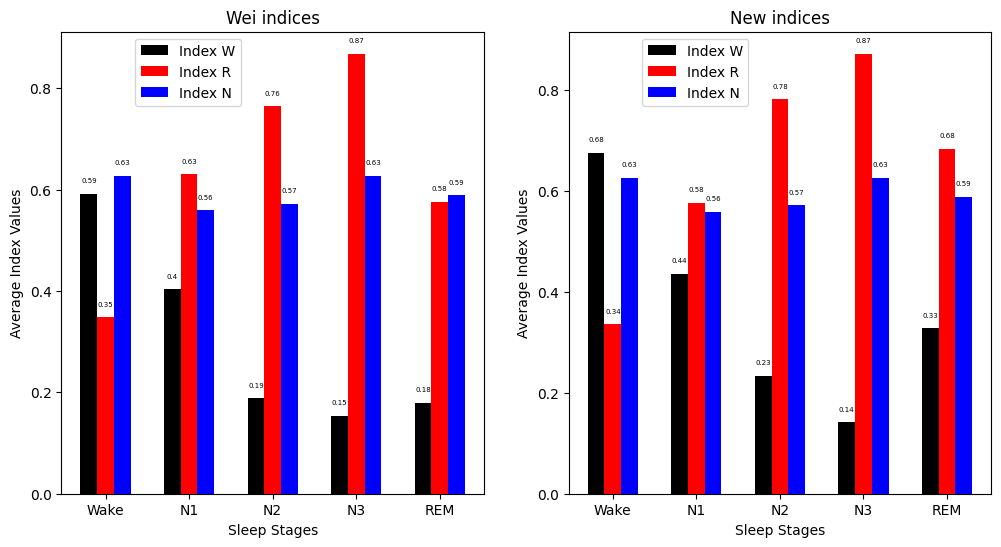

In [147]:
plt.figure(figsize=(12, 6))

# Wei indexes
plt.subplot(1, 2, 1)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [wake_w, n1_w, n2_w, n3_w, REM_w]
values_REM = [wake_r, n1_r, n2_r, n3_r, REM_r]
values_NREM = [wake_n, n1_n, n2_n, n3_n, REM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('Wei indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)




# New W index
plt.subplot(1, 2, 2)
categories = ['Wake', 'N1', 'N2','N3', 'REM']
index_types = ['Index_w', 'Index_r', 'Index_n']
values_wake = [nwake_w, nn1_w, nn2_w, nn3_w, nREM_w]
values_REM = [nwake_r, nn1_r, nn2_r, nn3_r, nREM_r]
values_NREM = [nwake_n, nn1_n, nn2_n, nn3_n, nREM_n]
x = np.arange(len(categories))
bar_width = 0.2
# Create bar plots
plt.bar(x - bar_width, values_wake, width=bar_width, label='Index W', color = 'black')
plt.bar(x, values_REM, width=bar_width, label='Index R', color = 'red',)
plt.bar(x + bar_width, values_NREM, width=bar_width, label='Index N', color = 'blue')
# Add labels and title
plt.xlabel('Sleep Stages')
plt.ylabel('Average Index Values')
plt.title('New indices')
plt.xticks(x, categories)
plt.legend(loc='upper center', bbox_to_anchor=(0.3, 1))

for i in range(len(categories)):
    plt.text(x[i] - bar_width, values_wake[i] + 0.02, str(round(values_wake[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i], values_REM[i] + 0.02, str(round(values_REM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
    plt.text(x[i] + bar_width, values_NREM[i] + 0.02, str(round(values_NREM[i], 2)), ha='center', va='bottom', fontsize=fontsize)
plt.savefig(f'{output_dir}/all_new_indices_vs_wei_barplot.svg', format='svg')
plt.show()

# 3D temporal visualisation of index evolution

In [148]:
import plotly.express as px
import pandas as pd

df = pd.DataFrame({
    'summed_emg': savgol_filter(EMG_norm, window_length=101, polyorder=4)[0:1000],               # you want to choose a time interval where you can see a whole wake-nrem-rem-nrem cycle
    'normalized_delta_power': savgol_filter(delta_norm, window_length=101, polyorder=4)[0:1000],  # extra smoothing so that we can actullay see something
    'normalized_theta_power': savgol_filter(theta_norm, window_length=101, polyorder=4)[0:1000]
})

fig = px.scatter_3d(df, x='normalized_theta_power', y='normalized_delta_power', z='summed_emg',
                    title='',
                    color=df.index,
                    color_continuous_scale='Magma',
                    opacity=0.8)

fig.update_layout(width=1000, height=900)
fig.show()

PCA data points:(4482, 3)


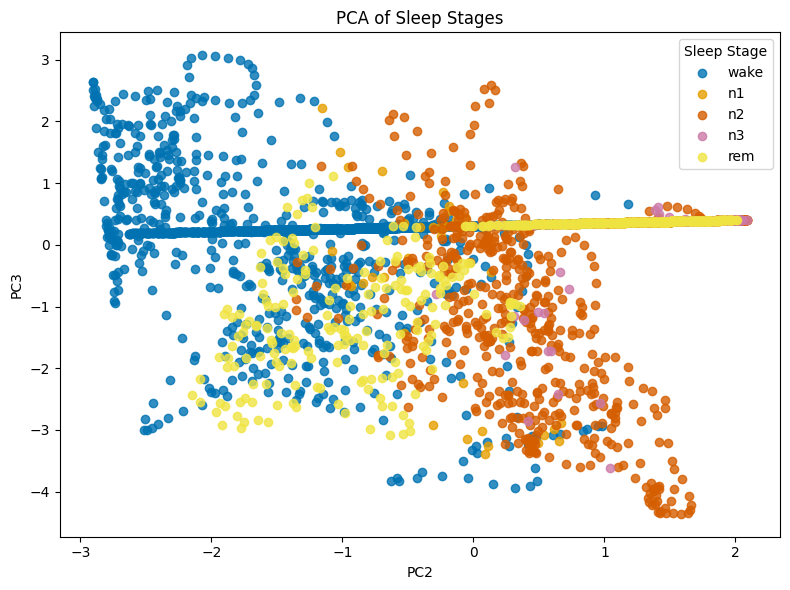

In [149]:
# mapped_scores_old = np.append(mapped_scores_old, [0,0])
difference = len(nindex_w_smoothed) - len(mapped_scores_old)
arrays = [
    nindex_w_smoothed[:-difference],
    index_n_smoothed[:-difference],
    nindex_r_smoothed[:-difference],
    mapped_scores_old
]
# print(f'epochs: {X.shape}')   # rows = number of samples (dots), columns = features
stage_map = {
    0.0: "wake",
    1.0: "n1",
    2.0: "n2",
    3.0: "n3",
    4.0: "rem"
}
array = np.column_stack(arrays)
df = pd.DataFrame(array)

x = df[[0, 1, 2]]
y = df[3]

scaler = StandardScaler()
X = x.to_numpy().astype(float)

# Replace NaNs with 0 (or another strategy like forward-fill)
X = np.nan_to_num(X, nan=0.0)
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

print(f'PCA data points:{X_pca.shape}')
# Colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#D55E00', '#CC79A7', '#F0E442']

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y)):
    stage_name = stage_map.get(label, str(label))  # fallback in case of unexpected value
    plt.scatter(
        X_pca[y==label, 0],
        X_pca[y==label, 1],
        label=stage_name,
        color=colors[i % len(colors)],
        alpha=0.8
    )

plt.xlabel("PC2")
plt.ylabel("PC3")
plt.title("PCA of Sleep Stages")
plt.legend(title="Sleep Stage")
plt.tight_layout()
plt.savefig(f"{output_dir}/Index_PCA_subject_2.svg", format='svg')
plt.show()

PCA data points:(4482, 2)


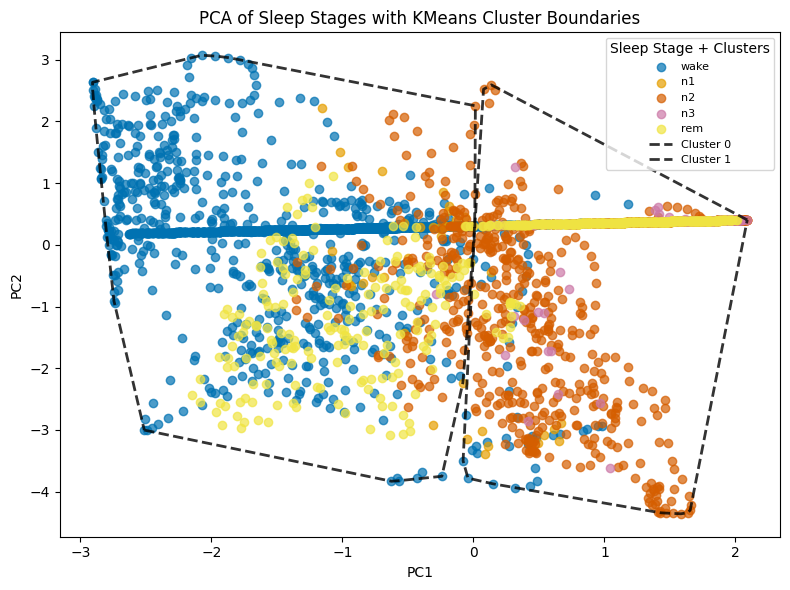

In [150]:
# mapped_scores_old = np.append(mapped_scores_old, [0,0])
difference = len(nindex_w_smoothed) - len(mapped_scores_old)
arrays = [
    nindex_w_smoothed[:-difference],
    index_n_smoothed[:-difference],
    nindex_r_smoothed[:-difference],
    mapped_scores_old
]
# print(f'epochs: {X.shape}')   # rows = number of samples (dots), columns = features
stage_map = {
    0.0: "wake",
    1.0: "n1",
    2.0: "n2",
    3.0: "n3",
    4.0: "rem"
}
array = np.column_stack(arrays)
df = pd.DataFrame(array)

x = df[[0, 1, 2]]
y = df[3]

scaler = StandardScaler()
X = x.to_numpy().astype(float)

# Replace NaNs with 0 (or another strategy like forward-fill)
X = np.nan_to_num(X, nan=0.0)
X_scaled = scaler.fit_transform(X)


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
from sklearn.cluster import KMeans

n_clusters = 2  
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(X_pca)

print(f'PCA data points:{X_pca.shape}')
# Colorblind-friendly palette
colors = ['#0072B2', '#E69F00', '#D55E00', '#CC79A7', '#F0E442']

from scipy.spatial import ConvexHull

plt.figure(figsize=(8,6))
for i, label in enumerate(np.unique(y)):
    stage_name = stage_map.get(label, str(label))
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label=stage_name,
        color=colors[i % len(colors)],
        alpha=0.7
    )

# --- Add cluster outlines ---
for i in range(n_clusters):
    points = X_pca[cluster_labels == i, :2]  # use first 2 PCs
    if len(points) >= 3:  # ConvexHull requires at least 3 points
        hull = ConvexHull(points)
        hull_points = points[hull.vertices]
        plt.plot(
            np.append(hull_points[:, 0], hull_points[0, 0]),
            np.append(hull_points[:, 1], hull_points[0, 1]),
            'k--', lw=2, alpha=0.8, label=f'Cluster {i}'
        )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Sleep Stages with KMeans Cluster Boundaries")
plt.legend(title="Sleep Stage + Clusters", fontsize=8)
plt.tight_layout()
plt.savefig(f"{output_dir}/Index_PCA_KMeans_Clusters_subject_2.svg", format='svg')
plt.show()
